<a href="https://colab.research.google.com/github/carlavilla/GIS/blob/main/map4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Colab is an online place (cloud) for running Python notebooks--we will use it to run our code :)

You can just edit and adjust and and run the notebook I gave you [this file!]: don't forget to first save it!!!: File-Save a copy in GitHub

And after adjusting to run with your own data, you can submit it as ps :)

After making edits, while can diff on GitHub, its clunky, better here: File-Revision History

make webbrowser fullscreen and collapse upper menu (arrow on the right), especially on laptop

There is built in AI Gemini that works well: suggests code (autocomplete in grey), explains error (like stack overflow), and can click on cell menu and Explain (explain the code)

(a sidenote: File-Download it and convert to pdf: https://2pdf.com/convert-ipynb-to-pdf)

In [ ]:
%%capture
#!pip install geopandas #==1.0.1
!pip install mapclassify #sometimes have to install library which you get from https://pypi.org/

In [ ]:
import os, zipfile #basics
import pandas as pd #data management
import matplotlib.pyplot as plt #vis

import geopandas as gpd #gis/maps: a sister of pandas; does the job;
#tho not as fancy-interactive as folium or leafmap https://geopandas.org/

import mapclassify #need for thematic map classification

import seaborn as sns

#will display all output not just last command
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from google.colab import files #to download from colab onto hd

#from google.colab import data_table
#data_table.enable_dataframe_formatter() #this enables spreadsheet view upon calling dataframe (without() )
from google.colab.data_table import DataTable
DataTable.max_columns = 250

In [ ]:
#!python --version
gpd.__version__

'1.1.1'

### [sep4] map your area of interest

say you are interested in NJ counties, so just google that geography + "shapefile", i.e., "NJ counties shapefile"

maps have their own files, a popular one is 'shapefile'--have it zipped--one shapefile consists of several files--keep them in one zipped folder and dont change their names

In [ ]:
#i found one and reposted on my website, download it onto colab:
! wget -q -O nj-.zip https://services1.arcgis.com/ze0XBzU1FXj94DJq/arcgis/rest/services/NJ%20municipalities%20shapefile/FeatureServer/0
#https://services1.arcgis.com/ze0XBzU1FXj94DJq/arcgis/rest/services/NJ%20municipalities%20shapefile/FeatureServer/0

zip_ref = zipfile.ZipFile('nj-counties.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping
njC0=gpd.read_file('nj_counties.shp') #load the shapefile with gpd as njC

##lets unpack, also good for debugging! comment out and do line by line
#also add handy !ls to see whats there

<Axes: >

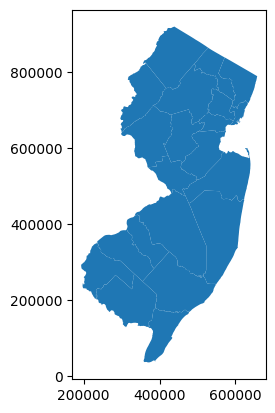

In [ ]:
#make the map
njC0.plot()

### [sep11] dive into thematic/choloropleth maps

 the key skill you will learn--we color code polygons (or lines or points) with levels of a variable, say green for low covid19, yellow for moderate, and red for high


REFS (also good for self study):

https://geographicdata.science/book/notebooks/05_choropleth.html
[like a textbook, good stuff like most by darribas (little wordy tho)]

https://geopandas.org/en/stable/gallery/choropleths.html

https://geopandas.org/en/stable/gallery/choro_legends.html

first, mapping var from gis datafile--rarely lucky and have the variable we want to map already in the shapefile

In [ ]:
! wget -q -O nj-counties.zip https://docs.google.com/uc?id=1xJDhcRCkgv7k4tNCa72Oog5bohV6dTB2&export=download
zip_ref = zipfile.ZipFile('nj-counties.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping
njC0=gpd.read_file('nj_counties.shp') #load the shapefile with gpd as njC

In [ ]:
njC0.dtypes #with geopandas can do stuff like with pandas :)
#njC0.info()

,0
COUNTY,object
COUNTY_LAB,object
CO,object
GNIS_NAME,object
GNIS,object
FIPSSTCO,object
FIPSCO,object
ACRES,float64
SQ_MILES,float64
POP2010,int64


In [ ]:
njC0.head(2)

,COUNTY,COUNTY_LAB,CO,GNIS_NAME,GNIS,FIPSSTCO,FIPSCO,ACRES,SQ_MILES,POP2010,...,POP1990,POP1980,POPDEN2010,POPDEN2000,POPDEN1990,POPDEN1980,REGION,Shape_Leng,Shape_Area,geometry
0,ATLANTIC,Atlantic County,ATL,County of Atlantic,882270,34001,1,390815.404215,610.649069,274549,...,275372,204615,450,414,451,335,COASTAL,650228.153906,1.702385e+10,"POLYGON ((443056.01 311529.77, 443068.44 31152..."
1,BERGEN,Bergen County,BER,County of Bergen,882271,34003,3,153490.275182,239.828555,905116,...,829592,849843,3774,3686,3459,3544,NORTHEASTERN,443326.122021,6.686010e+09,"POLYGON ((656200.963 783614.366, 656141.127 78..."


In [ ]:
#keep it simple! always do it! and do it early!
njC=njC0[['COUNTY','COUNTY_LAB','POP2010','POPDEN2010','geometry']]

In [ ]:
njC.info() #have a look at the data

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   COUNTY      21 non-null     object  
 1   COUNTY_LAB  21 non-null     object  
 2   POP2010     21 non-null     int64   
 3   POPDEN2010  21 non-null     int64   
 4   geometry    21 non-null     geometry
dtypes: geometry(1), int64(2), object(2)
memory usage: 972.0+ bytes


In [ ]:
njC.COUNTY.value_counts(dropna=False) #any duplicates or missing

,count
COUNTY,
ATLANTIC,1
BERGEN,1
BURLINGTON,1
CAMDEN,1
CAPE MAY,1
CUMBERLAND,1
ESSEX,1
GLOUCESTER,1
HUDSON,1


<Axes: >

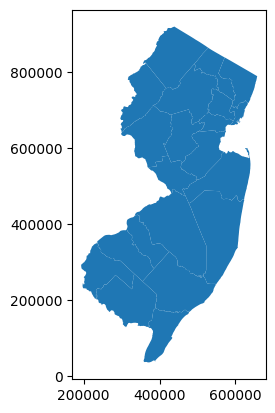

In [ ]:
njC.plot() #yay love the shape

<Axes: >

[]

[]

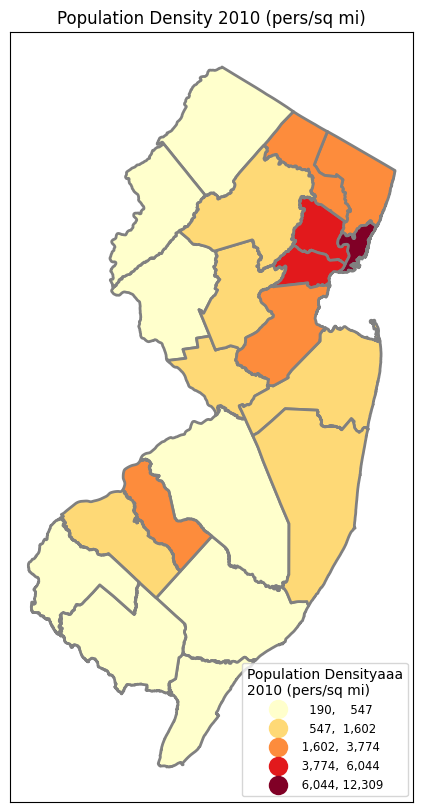

In [ ]:
#THIS IS THE KEY CODE: keep it mind, come back to it, use it, understand it
#may put lots of comments here too
#first thematic map! lets unpack options esp fmt for dec pts; more later sec 'bells and whistles'
fig, ax = plt.subplots(1, figsize=(6,10))
njC.plot(ax=ax,column='POPDEN2010',legend=True,cmap='YlOrRd',scheme='natural_breaks',k=5,
         edgecolor='grey',linewidth=2,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4}) #
#leg1 = ax.get_legend()
#leg1.set_title('''Population Density #this is legend title; useful!
#2010 (pers/sq mi)''')
ax.title.set_text("Population Density 2010 (pers/sq mi)")
ax.set_xticks([]) #kills xticks
ax.set_yticks([]) #kills xticks
#plt.savefig('fig.pdf',bbox_inches='tight') #,pad_inches=0.1, dpi=200, transparent=True #eps, jpeg, jpg, pdf, pgf, png, ps, raw, rgba, svg, svgz, tif, tiff
#files.download('fig.pdf') #note can also right click fig and save image as

#btw for afficcionados, yes can further adjust the legend:
#https://stackoverflow.com/questions/52503899/format-round-numerical-legend-label-in-geopandas

In [ ]:
# we can overlay layers; lets get nj uni shapefile on it
!wget -q -O col.zip  https://docs.google.com/uc?id=1bb9KES6QDE7cleE4L38yQ7939LlXUHB5&export=download
zip_ref = zipfile.ZipFile('col.zip', 'r');zip_ref.extractall(); zip_ref.close()

col = gpd.read_file('2007_11_30_NJ_COLL_UNIV_njsp.shp')
col.dtypes
col.head(3)

,0
ID,object
METLNKID,object
FEATTYPE,object
SECCLASS,object
NAME,object
AREA,object
PHONE,object
ADDRESS,object
ADDRESS2,object
CITY,object


,ID,METLNKID,FEATTYPE,SECCLASS,NAME,AREA,PHONE,ADDRESS,ADDRESS2,CITY,...,X,Y,ST_VENDOR,ST_VERSION,GEOPREC,PHONELOC,QC_QA,DEGREE,ENROLL,geometry
0,10273936,None,POINT,UNCLASSIFIED,RAMAPO COLLEGE OF NEW JERSEY,201,684-7500,505 RAMAPO VALLEY RD,None,MAHWAH,...,-74.177826,41.082642,NAVTEQ,2006Q4,BLOCKFACE,None,None,MASTER'S DEGREE,5538,POINT (580936.143 819465.262)
1,10273934,None,POINT,UNCLASSIFIED,NEW BRUNSWICK THEOLOGICAL SEMINARY,732,247-5241,17 SEMINARY PL,None,NEW BRUNSWICK,...,-74.448814,40.501346,NAVTEQ,2006Q4,BLOCKFACE,None,None,DOCTOR'S DEGREE,203,POINT (506358.894 607539.257)
2,10273932,None,POINT,UNCLASSIFIED,MONMOUTH UNIVERSITY,732,571-3400,400 CEDAR AVE,None,WEST LONG BRANCH,...,-74.003765,40.281505,NAVTEQ,2006Q4,BLOCKFACE,None,None,POST-MASTER'S CERTIFICATE,6351,POINT (630565.964 527840.459)


In [ ]:
col['enr'] = col.ENROLL.astype(float)

<Axes: >

<Axes: >

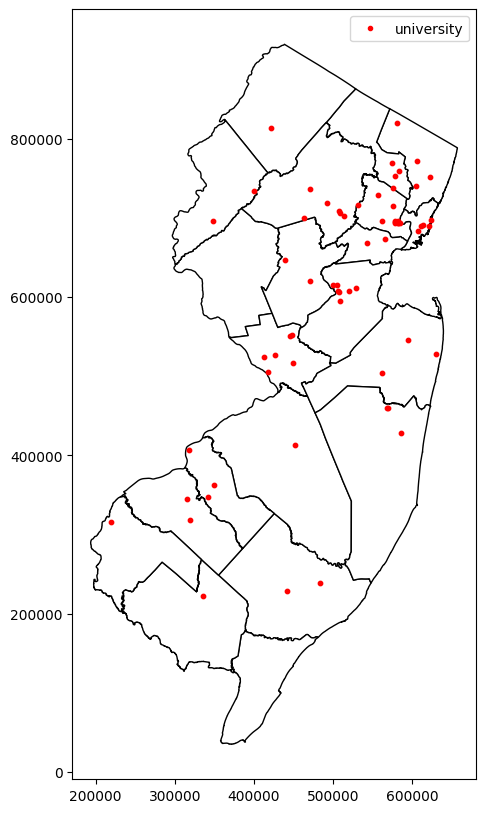

In [ ]:
#and now overlay: just use plot fn twice; remember: most maps are layered
fig, ax = plt.subplots(1, figsize=(6,10))
njC.plot(ax=ax, color='white', edgecolor='black',linewidth=1)
col.plot(ax=ax, marker='o', color='red', markersize=10,legend=True)
#col.plot(column='enr',markersize=50,legend=True,cmap='RdYlGn_r',scheme='QUANTILES',k=5,ax=ax)
#ax.set_title('Watersheds by area ($mi^2$)')

#custom legend
#https://stackoverflow.com/questions/39500265/how-to-manually-create-a-legend
#import matplotlib.patches as mpatches
#red_patch = mpatches.Patch(color='red', label='The red data')
from matplotlib.lines import Line2D
point = Line2D([0], [0], label='university', marker='o', markersize=3,
         markeredgecolor='r', markerfacecolor='r', linestyle='')
plt.legend(handles=[point])

## join/merge
 awesome power! use it a lot

make it easy on yourself--work smart, not hard! so simplify or subset:
say instead of 200 little indian regions just do 20 big provinces; and instead of 50 convoluted variables, just retain 5<br>

merge may get difficult (especially if difficult data so again simplify): if you need more power:

https://colab.research.google.com/github/theaok/datManPy/blob/main/pandas.ipynb#scrollTo=dMPPOPS92WkA

<br>

 <br>we will cover how to map multiple variables in one map later; for now just use 2 separate maps; and calculate new variables! for instance instead of having 2 maps for crime in 1970 and 2000 just have percent difference: 100*(crim2000-crim1970)/crim1970

### housing/zillow example

say want to map housing values across nj counties

first get the counties shp (already got it)

now get regular data with housing values and merge with counties shp

and finaly color code the polygons with housing values




#### zillow dat man
(again note can collapse and run all at once)

housing prices for NJ counties (i just googled 'housing prices data') (http://www.zillow.com/research/data):

https://github.com/theaok/data/raw/main/NJ-counties-Zillow-Home-Value-Index-TimeSeries.xls



adjust ID: make counties uppercase (or could drop 'County' from COUNTY LABEL variable)


and clean up:  drop first row if junk in it, excessive columns, \$ \%,\#, etc

code everything so the end product is like:

https://raw.githubusercontent.com/theaok/data/main/all_homes.csv


In [ ]:
zilXls=pd.read_excel('https://github.com/theaok/data/raw/main/NJ-counties-Zillow-Home-Value-Index-TimeSeries.xls')

In [ ]:
zilXls.head(2)

,NJ Zillow Home Value Index - All Homes,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 194,Unnamed: 195,Unnamed: 196,Unnamed: 197,Unnamed: 198,Unnamed: 199,Unnamed: 200,Unnamed: 201,Unnamed: 202,Unnamed: 203
0,Region Name,Region Type,Data Type,1996-04-15 00:00:00,1996-05-15 00:00:00,1996-06-15 00:00:00,1996-07-15 00:00:00,1996-08-15 00:00:00,1996-09-15 00:00:00,1996-10-15 00:00:00,...,2012-03-15 00:00:00,2012-04-15 00:00:00,2012-05-15 00:00:00,2012-06-15 00:00:00,2012-07-15 00:00:00,2012-08-15 00:00:00,2012-09-15 00:00:00,2012-10-15 00:00:00,2012-11-15 00:00:00,2012-12-15 00:00:00
1,New Jersey,state,All Homes,130200,129700,129700,130000,129500,128400,130300,...,256600,257000,257000,257100,256600,256100,256900,258300,259100,259700


In [ ]:
zilXls.dtypes
#zilXls.info(verbose=True)

,0
NJ Zillow Home Value Index - All Homes,object
Unnamed: 1,object
Unnamed: 2,object
Unnamed: 3,object
Unnamed: 4,object
...,...
Unnamed: 199,object
Unnamed: 200,object
Unnamed: 201,object
Unnamed: 202,object


In [ ]:
zilXls1=zilXls[['NJ Zillow Home Value Index - All Homes','Unnamed: 203']]
zilXls1.rename(columns={'NJ Zillow Home Value Index - All Homes': 'county'}, inplace=True)
zilXls1.rename(columns={'Unnamed: 203': 'dec2012'}, inplace=True)
zilXls1

/tmp/ipython-input-598143840.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zilXls1.rename(columns={'NJ Zillow Home Value Index - All Homes': 'county'}, inplace=True)
/tmp/ipython-input-598143840.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zilXls1.rename(columns={'Unnamed: 203': 'dec2012'}, inplace=True)


,county,dec2012
0,Region Name,2012-12-15 00:00:00
1,New Jersey,259700
2,Atlantic,185800
3,Bergen,380000
4,Burlington,197800
5,Camden,149400
6,Cape May,313600
7,Cumberland,120100
8,Essex,282800
9,Gloucester,175900


In [ ]:
zilXls2=zilXls1.iloc[1:, :] #drop first obs
zilXls2 #note missing val for Morris; always think abt missing data!

,county,dec2012
1,New Jersey,259700
2,Atlantic,185800
3,Bergen,380000
4,Burlington,197800
5,Camden,149400
6,Cape May,313600
7,Cumberland,120100
8,Essex,282800
9,Gloucester,175900
10,Hudson,293100


In [ ]:
zilXls2['COUNTY']=zilXls2['county'].str.upper()
zil1=zilXls2
zil1

/tmp/ipython-input-4130304316.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zilXls2['COUNTY']=zilXls2['county'].str.upper()


,county,dec2012,COUNTY
1,New Jersey,259700,NEW JERSEY
2,Atlantic,185800,ATLANTIC
3,Bergen,380000,BERGEN
4,Burlington,197800,BURLINGTON
5,Camden,149400,CAMDEN
6,Cape May,313600,CAPE MAY
7,Cumberland,120100,CUMBERLAND
8,Essex,282800,ESSEX
9,Gloucester,175900,GLOUCESTER
10,Hudson,293100,HUDSON


In [ ]:
#obsolete (was loading cleaned up already data without cleaning in py)
#!wget -q -O zillow.csv  https://docs.google.com/uc?id=1Q4tCZT0EfaJP_WGwKcxuPaQ_dDFonW4E&export=download
#!wget -q -O zil0.csv https://raw.githubusercontent.com/theaok/data/main/all_homes.csv
#zil0=pd.read_csv('zil0.csv')
#zil0.head(3)
#zil1=zil0[['UPPER','Dec 2012']]
#zil1.rename(columns={'UPPER': 'COUNTY'}, inplace=True) #fix col names to match 1st dataset
#zil1 #note missing val for Morris; always think abt missing data!

#### zillow merge and map

In [ ]:
#merge
njC1 = pd.merge(njC, zil1, on='COUNTY',how='outer',indicator=True) #(make sure to have njC shapefile from previous sec)
njC1[['COUNTY','dec2012','POPDEN2010','_merge']] #all good, NEW JERSEY expected not to merge
#!!!always inwestigate the merge result and always briefly explain it!!!

,COUNTY,dec2012,POPDEN2010,_merge
0,ATLANTIC,185800,450.0,both
1,BERGEN,380000,3774.0,both
2,BURLINGTON,197800,547.0,both
3,CAMDEN,149400,2257.0,both
4,CAPE MAY,313600,340.0,both
5,CUMBERLAND,120100,313.0,both
6,ESSEX,282800,6044.0,both
7,GLOUCESTER,175900,857.0,both
8,HUDSON,293100,12309.0,both
9,HUNTERDON,327000,293.0,both


In [ ]:
njC2 = pd.merge(njC, zil1, on='COUNTY',how='inner',indicator=False) #so do 'inner' that will only keep the exact matches

<Axes: >

[]

[]

Text(0.5, 80.7222222222222, 'source/definition: zillow.com/research/data')

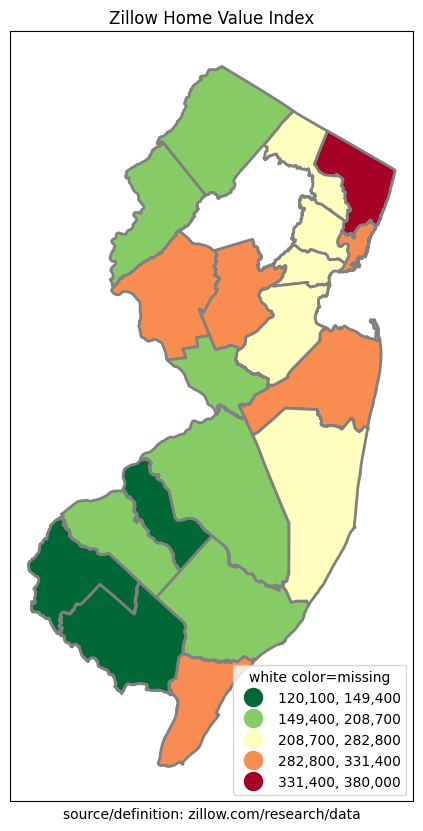

In [ ]:
fig, ax = plt.subplots(1, figsize=(6,10))
njC2.plot(ax=ax,column='dec2012',legend=True,cmap='RdYlGn_r',
          scheme='natural_breaks',k=5, edgecolor='grey',linewidth=2,
          legend_kwds= {"fmt": "{:,.0f}",'loc':'lower right','markerscale':1.4})
leg1 = ax.get_legend()
leg1.set_title('''white color=missing''')
ax.title.set_text("Zillow Home Value Index")
ax.set_xticks([]) #kills xticks
ax.set_yticks([]) #kills xticks
ax.set_xlabel('''source/definition: zillow.com/research/data''')
#plt.savefig('fig.pdf',bbox_inches='tight') #,pad_inches=0.1, dpi=200, transparent=True #eps, jpeg, jpg, pdf, pgf, png, ps, raw, rgba, svg, svgz, tif, tiff
#files.download('fig.pdf') #note can also right click fig and save image as

###  abortions example

In [ ]:
#as of sep2025 this download doesnt work anymore

# get data: https://data.guttmacher.org/ has a nice API
# can click thru to get the table we want, which results in url (can open in webbrowser):
# https://data.guttmacher.org/counties/table?county=34001+34003+34005+34007+34009+34011+34013+34015+34017+34019+34021+34023+34025+34027+34029+34031+34033+34035+34037+34039+34041&topics=244+247&dataset=data&state=NJ
# and then can right click on 'download xls' (csv is messy in this case) button under the table and 'copy link address' and paste into wget (need quotes!):
#!wget -q -O njAb0.xls  "https://data.guttmacher.org/download?locationType=county&visualization=datatable&topic=244+247&locations=34001+34003+34005+34007+34009+34011+34013+34015+34017+34019+34021+34023+34025+34027+34029+34031+34033+34035+34037+34039+34041&measures=424+425+426+427+428+429+436+437+438+439+440+441+442&totalKey=NJ"

# alternatively can scrap the table
#import requests
#url = 'https://data.guttmacher.org/counties/table?county=34001+34003+34005+34007+34009+34011+34013+34015+34017+34019+34021+34023+34025+34027+34029+34031+34033+34035+34037+34039+34041&topics=244+247&dataset=data&state=NJ'
#header = {
#  "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/50.0.2661.75 Safari/537.36",
#  "X-Requested-With": "XMLHttpRequest"
#}
#r = requests.get(url, headers=header)
#pd.read_html(r.text,match='U.S. County',flavor=None)[0].head(3) #for match just putting name of first col

#njAb0=pd.read_excel('njAb0.xls')
#njAb0.head(3)
#njAb0.columns
#njAb=njAb0[['U.S. County','Total publicly funded clinics, 2015 [1]']] #keep it simple

In [ ]:
njAb=pd.read_csv('https://raw.githubusercontent.com/theaok/data/refs/heads/main/abortions.csv')
njAb.rename(columns={'COUNTY': 'U.S. County'}, inplace=True)
njAb.head(3)

,U.S. County,"Total publicly funded clinics, 2015 [1]"
0,ATLANTIC,6
1,BERGEN,6
2,BURLINGTON,4


In [ ]:
#look at shapefile cnty names
njC.COUNTY_LAB #(make sure to have njC shapefile from previous sec)

,COUNTY_LAB
0,Atlantic County
1,Bergen County
2,Burlington County
3,Camden County
4,Cape May County
5,Cumberland County
6,Essex County
7,Gloucester County
8,Hudson County
9,Hunterdon County


In [ ]:
njC['U.S. County']=njC['COUNTY_LAB'].str.replace(' County','') #get rid of ' County' [note space in front of county]
njC['U.S. County']=njC['U.S. County'].str.upper() #make uppercase
njC['U.S. County'].head(3)

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,U.S. County
0,ATLANTIC
1,BERGEN
2,BURLINGTON


In [ ]:
njCAb = pd.merge(njC, njAb, on='U.S. County',how='outer',indicator=True)
njCAb[['COUNTY','Total publicly funded clinics, 2015 [1]','_merge']].head(50) # ok
#njCAb = pd.merge(njC, njAb, on='U.S. County',how='inner',indicator=True) #inner merge
#njCAb

,COUNTY,"Total publicly funded clinics, 2015 [1]",_merge
0,ATLANTIC,6,both
1,BERGEN,6,both
2,BURLINGTON,4,both
3,CAMDEN,10,both
4,CAPE MAY,4,both
5,CUMBERLAND,6,both
6,ESSEX,15,both
7,GLOUCESTER,3,both
8,HUDSON,14,both
9,HUNTERDON,1,both


In [ ]:
njCAb.dtypes

,0
COUNTY,object
COUNTY_LAB,object
POP2010,int64
POPDEN2010,int64
geometry,geometry
U.S. County,object
"Total publicly funded clinics, 2015 [1]",int64
_merge,category


In [ ]:
#often (not here) need to convert string (object) to numeric (float or int; float is safer can have decimals if needed)
njCAb['publicly funded clinics, 2015'] = njCAb['Total publicly funded clinics, 2015 [1]'].astype(float)

In [ ]:
njCAb[['U.S. County','Total publicly funded clinics, 2015 [1]','publicly funded clinics, 2015']]

,U.S. County,"Total publicly funded clinics, 2015 [1]","publicly funded clinics, 2015"
0,ATLANTIC,6,6.0
1,BERGEN,6,6.0
2,BURLINGTON,4,4.0
3,CAMDEN,10,10.0
4,CAPE MAY,4,4.0
5,CUMBERLAND,6,6.0
6,ESSEX,15,15.0
7,GLOUCESTER,3,3.0
8,HUDSON,14,14.0
9,HUNTERDON,1,1.0


<Axes: >

Text(0.5, 1.0, 'count of publicly funded abortion clinics, 2015')

Text(0.5, 0.1, 'data from guttmacher.org\n            Publicly Funded Contraceptive Services at U.S. Clinics, 2015, Frost JJ, et al., 2017')

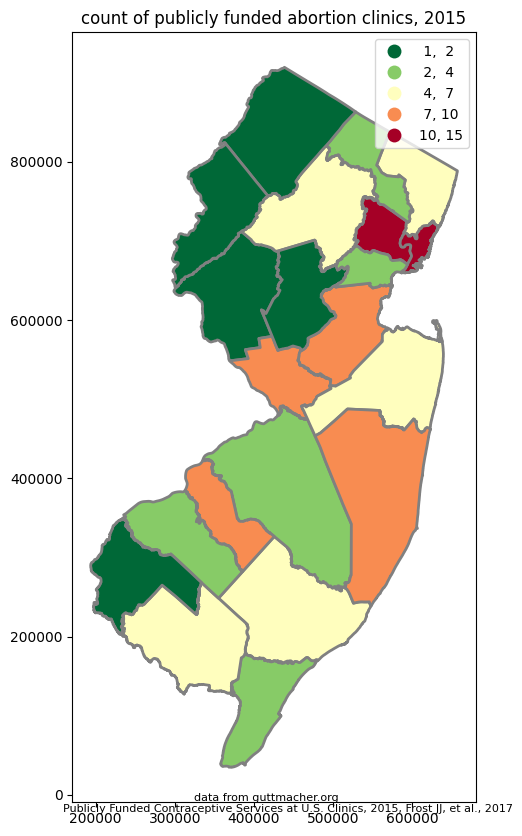

In [ ]:
fig, ax = plt.subplots(figsize=(6,10))

njCAb.plot(ax=ax,figsize=(10,12),column='publicly funded clinics, 2015',legend=True,cmap='RdYlGn_r',
          scheme='natural_breaks',k=5, edgecolor='grey',linewidth=2,legend_kwds= {"fmt": "{:,.0f}"})
#ax.set_xticks([]) #kills xticks
#ax.set_yticks([]) #kills xticks
ax.set_title('count of publicly funded abortion clinics, 2015')
#ax.annotate('Note added to chart with minimum parameters', xy = (200000, 1000))
plt.figtext(0.5, 0.1,
            '''data from guttmacher.org
            Publicly Funded Contraceptive Services at U.S. Clinics, 2015, Frost JJ, et al., 2017''',
            ha="center", fontsize=8, #bbox={"facecolor":"white", "alpha":0.5, "pad":5}
            )

### [sep18] us census data example

census is a great source of data, even at neigh lev!

for neigh lev (census tracts)  want 5-yr ACS (so that the standard errors on estimates for these tiny areas are not too huge)

https://geomap.ffiec.gov/FFIECGeocMap/GeocodeMap1.aspx


SKIP (instead do user-friendly socialexplorer below):

https://data.census.gov/cedsci/advanced

Geography: Tract: New Jersey: Camden County: All Census Tracts within Camden County

note: selection appears in the left panel

Topics: Income and Poverty: Poverty: Official Poverty Measure

Years: 2015

Search

click ``POVERTY STATUS IN THE PAST 12 MONTHS''  (ACS2011-2015 S1701)

(take note of margins of errors)

sure can transpose and download as csv but its a mess!




one rule to guide us is to be lazy/work smart, not hard

just find a decent alternative to clunky/messy census such as:

socialexplorer.com (free on-campus or vpn)

Tables: ACS 2015-2019

SE:A13003B. Poverty Status in 2019 for Population Age 18 to 64

tracts in camden county nj

downloaded as csv and reposted:
https://raw.githubusercontent.com/theaok/data/main/R13437109_SL140.csv



In [ ]:
!wget -q -O pov0.csv https://raw.githubusercontent.com/theaok/data/main/R13437109_SL140.csv

pov0=pd.read_csv('pov0.csv')
pov0.head(3)

,Geo_FIPS,Geo_GEOID,Geo_NAME,Geo_QName,Geo_STUSAB,Geo_SUMLEV,Geo_GEOCOMP,Geo_FILEID,Geo_LOGRECNO,Geo_US,...,Geo_PCI,Geo_TAZ,Geo_UGA,Geo_BTTR,Geo_BTBG,Geo_PUMA5,Geo_PUMA1,SE_A13003B_001,SE_A13003B_002,SE_A13003B_003
0,34007600200,14000US34007600200,Census Tract 6002,"Census Tract 6002, Camden County, New Jersey",nj,140,0,ACSSF,1761,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1398,405,993
1,34007600400,14000US34007600400,Census Tract 6004,"Census Tract 6004, Camden County, New Jersey",nj,140,0,ACSSF,1762,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1793,725,1068
2,34007600700,14000US34007600700,Census Tract 6007,"Census Tract 6007, Camden County, New Jersey",nj,140,0,ACSSF,1763,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,847,394,453


In [ ]:
#as per the above documentation we see percent poor is
#number of poor people divided by population: SE_A13003B_002/SE_A13003B_001
pov0['pov']=(pov0.SE_A13003B_002/pov0.SE_A13003B_001)*100
pov=pov0[['pov','Geo_NAME']]
pov

,pov,Geo_NAME
0,28.969957,Census Tract 6002
1,40.435025,Census Tract 6004
2,46.517119,Census Tract 6007
3,41.643929,Census Tract 6008
4,47.969656,Census Tract 6009
...,...,...
122,6.073211,Census Tract 6113
123,5.392517,Census Tract 6114
124,5.954142,Census Tract 6115
125,16.037063,Census Tract 6116


get geo data

https://www.census.gov/geo/maps-data/data/tiger-line.html

Download-Web Interface: 2019: Census Tracts: New Jersey

reposted:
https://github.com/theaok/data/raw/main/tl_2019_34_tract.zip

In [ ]:
! wget -q -O tracts.zip https://github.com/theaok/data/raw/main/tl_2019_34_tract.zip
zip_ref = zipfile.ZipFile('tracts.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping
#! ls
tracts=gpd.read_file('tl_2019_34_tract.shp')

<Axes: >

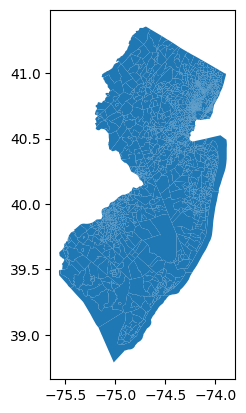

In [ ]:
#%%capture
tracts.plot() #humongous, thousands of tracts!

In [ ]:
tracts.dtypes

,0
STATEFP,object
COUNTYFP,object
TRACTCE,object
GEOID,object
NAME,object
NAMELSAD,object
MTFCC,object
FUNCSTAT,object
ALAND,int64
AWATER,int64


In [ ]:
#tracts.head(3) #commented out because a lot of output; but have a look: geometries: x/y or lat/lon

In [ ]:
tracts["COUNTYFP"].value_counts(dropna=False)

,count
COUNTYFP,
013,210
003,179
023,175
017,166
025,144
007,127
029,126
005,114
039,108


google county codes:

https://www.google.com/search?client=firefox-b-1-d&q=nj+counties+fips+codes

https://en.wikipedia.org/wiki/List_of_counties_in_New_Jersey

In [ ]:
tractsCam=tracts[tracts.COUNTYFP=='007']

<Axes: >

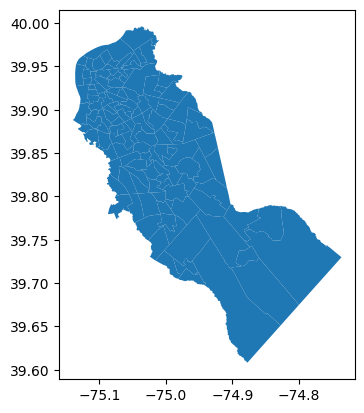

In [ ]:
tractsCam.plot() #yay

In [ ]:
tractsCam.NAMELSAD

,NAMELSAD
174,Census Tract 6071
175,Census Tract 6072
176,Census Tract 6073
177,Census Tract 6074.01
212,Census Tract 6004
...,...
1860,Census Tract 6060
1861,Census Tract 6010
1862,Census Tract 6092.05
1863,Census Tract 6082.09


In [ ]:
a1 = pd.merge(tractsCam, pov, left_on='NAMELSAD', right_on='Geo_NAME',how='outer',indicator=True)

In [ ]:
a1['_merge'].value_counts() #yay

,count
_merge,
both,127
left_only,0
right_only,0


<Axes: >

[]

[]

Text(0.5, 80.7222222222222, 'source/var def: socialexplorer.com/tables/ACS2019_5yr/R13437109')

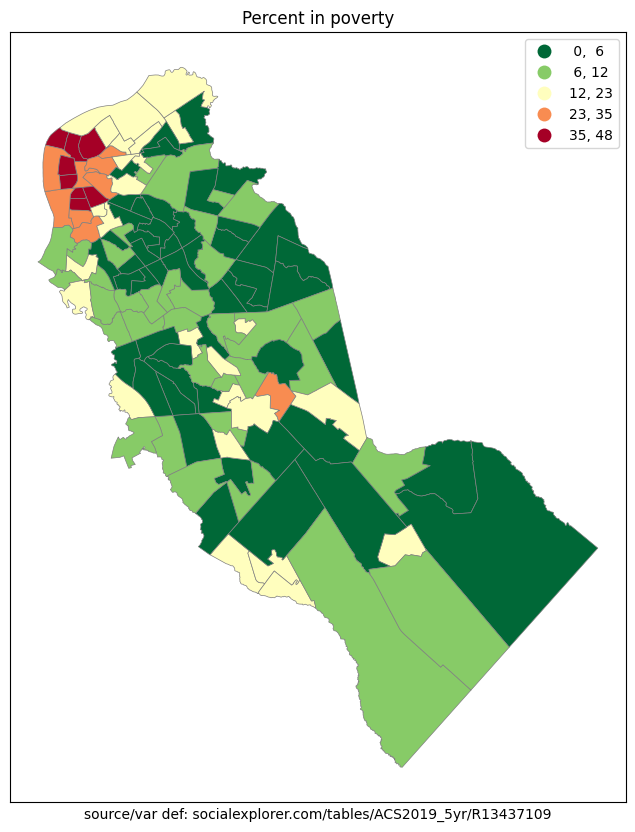

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
a1.plot(ax=ax,column='pov',legend=True,cmap='RdYlGn_r',
          scheme='natural_breaks',k=5, edgecolor='grey',linewidth=.5,legend_kwds= {"fmt": "{:,.0f}"})
ax.title.set_text("Percent in poverty")
ax.set_xticks([]) #kills xticks
ax.set_yticks([]) #kills xticks
ax.set_xlabel('''source/var def: socialexplorer.com/tables/ACS2019_5yr/R13437109''')

# [oct2] bells+whistles/geoprocessing

we did basic easy mapping, but there's more to it

everyone needs schemes (classification), and the rest just pick what's useful for you!


### schemes (classification)

elaboration and details:
https://geographicdata.science/book/notebooks/05_choropleth.html

(['boxplot', 'equalinterval', 'fisherjenks', 'fisherjenkssampled', 'headtailbreaks', 'jenkscaspall', 'jenkscaspallforced', 'jenkscaspallsampled', 'maxp', 'maximumbreaks', 'naturalbreaks', 'quantiles', 'percentiles', 'prettybreaks', 'stdmean', 'userdefined'])

<Axes: >

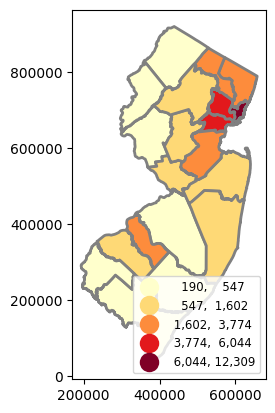

In [ ]:
njC.plot(column='POPDEN2010',legend=True,cmap='YlOrRd',scheme='natural_breaks',k=5,
         edgecolor='grey',linewidth=2,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4})

Don't forget to map out data owith histograms to look at the general distribution. The breaks in the thematic maps may not reflect the data breakup as you'd need it. </br>
Make sure to specify why you selected a given type of break, especially if customized (see below).

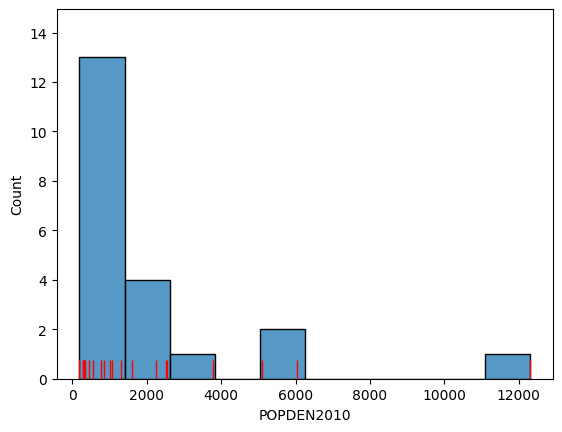

In [ ]:
#do think how distribution translate into colors!!
#njC.POPDEN2010.hist(bins=10) #super skewed!
ax = sns.histplot(njC["POPDEN2010"], bins=10)
sns.rugplot(njC["POPDEN2010"], height=0.05, color="red", ax=ax);

<Axes: >

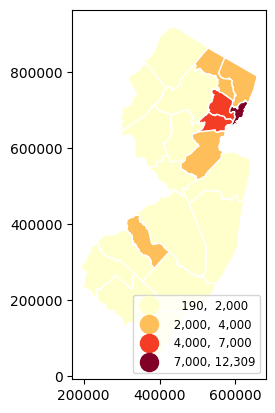

In [ ]:
#your own classification: 2k looks like good cutoff, then 4k and 7k
njC.plot(column="POPDEN2010", scheme="user_defined", cmap="YlOrRd", classification_kwds={'bins':[2000, 4000, 7000]},
         linewidth=1,edgecolor='white', legend=True,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4})


,POPDEN2010
14,190
16,279
9,293
18,300
5,313
4,340
0,450
2,547
12,761
7,857


<Axes: >

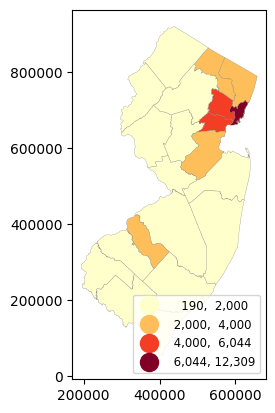

In [ ]:
njC.POPDEN2010.sort_values()
#note the bin is upto val with it; and next one is from it without it
njC.plot(column="POPDEN2010", scheme="user_defined", cmap="YlOrRd", classification_kwds={'bins':[2000, 4000, 6044]},
         linewidth=.2,edgecolor='grey', legend=True,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4})
#note that bins indicate the upper limit of that bin. The legend will read that the next category starts from that upper limit as the lower limit,
#but that lower limit will actually be in the previous category, not the one where it's the lower limt.

### simplify geo

In [ ]:
! wget -q -O nj-counties.zip https://docs.google.com/uc?id=1xJDhcRCkgv7k4tNCa72Oog5bohV6dTB2&export=download
zip_ref = zipfile.ZipFile('nj-counties.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping
njC0=gpd.read_file('nj_counties.shp')
njC=njC0[['COUNTY','COUNTY_LAB','POP2010','POPDEN2010','geometry']]

In [ ]:
njC.dtypes

,0
COUNTY,object
COUNTY_LAB,object
POP2010,int64
POPDEN2010,int64
geometry,geometry


<Axes: >

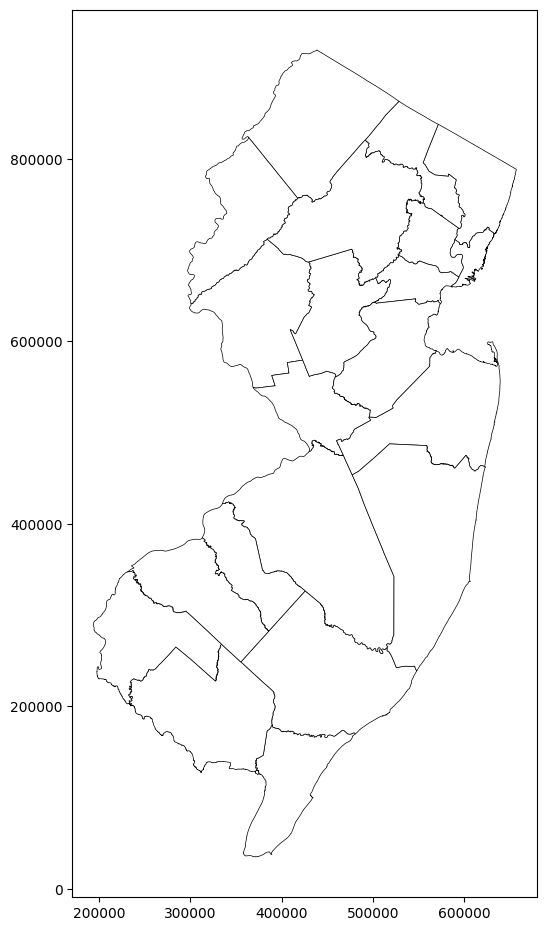

In [ ]:
njC.plot(figsize=(6,12), color='white', edgecolor='black',linewidth=.5)

<Axes: >

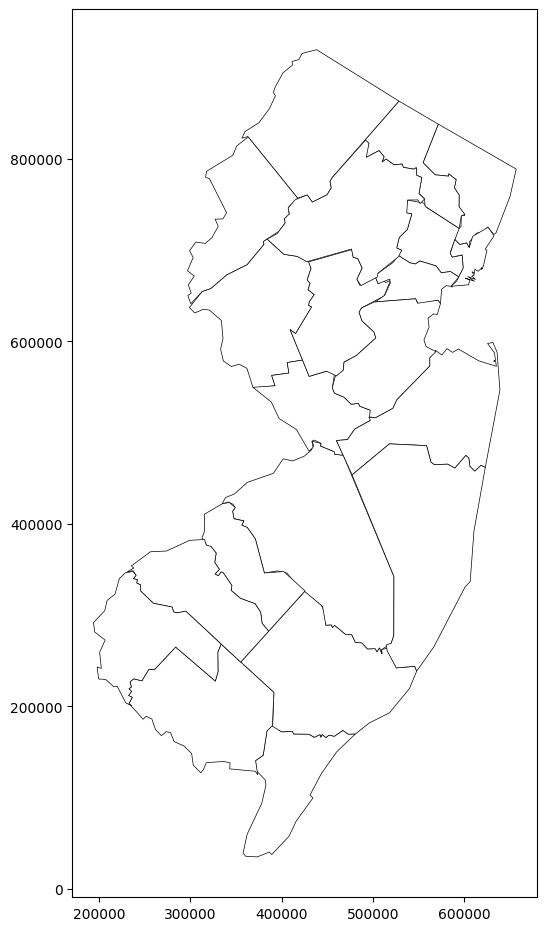

In [ ]:
njC1=njC.copy()
njC1['geometry'] = njC1.simplify(tolerance=2000)
njC1.plot(figsize=(6,12), color='white', edgecolor='black',linewidth=.5)

### I/O
(in gpd < 1 was fiona, now pyogrio (both gdal wrappers); btw command line ogr2ogr super powerfull)

In [ ]:
#%%capture
#!pip install fiona

In [ ]:
#import fiona
# bunch of available drivers are unexposed but supported (depends on the GDAL-build)
# https://github.com/Toblerity/Fiona/blob/main/fiona/drvsupport.py
# https://gdal.org/en/stable/drivers/vector/index.html
# can activate these on runtime by updating the supported_drivers dictionary:
# fiona.supported_drivers["NAS"] = "raw"
#fiona.supported_drivers['KML'] = 'rw'
#fiona.supported_drivers

In [ ]:
import pyogrio; pyogrio.list_drivers()

{'PCIDSK': 'rw',
 'PDS4': 'rw',
 'VICAR': 'rw',
 'PDF': 'rw',
 'MBTiles': 'rw',
 'EEDA': 'r',
 'OGCAPI': 'r',
 'ESRI Shapefile': 'rw',
 'MapInfo File': 'rw',
 'UK .NTF': 'r',
 'LVBAG': 'r',
 'OGR_SDTS': 'r',
 'S57': 'rw',
 'DGN': 'rw',
 'OGR_VRT': 'r',
 'Memory': 'rw',
 'CSV': 'rw',
 'GML': 'rw',
 'GPX': 'rw',
 'KML': 'rw',
 'GeoJSON': 'rw',
 'GeoJSONSeq': 'rw',
 'ESRIJSON': 'r',
 'TopoJSON': 'r',
 'OGR_GMT': 'rw',
 'GPKG': 'rw',
 'SQLite': 'rw',
 'WAsP': 'rw',
 'OpenFileGDB': 'rw',
 'DXF': 'rw',
 'FlatGeobuf': 'rw',
 'Geoconcept': 'rw',
 'GeoRSS': 'rw',
 'VFK': 'r',
 'PGDUMP': 'rw',
 'OSM': 'r',
 'GPSBabel': 'rw',
 'OGR_PDS': 'r',
 'WFS': 'r',
 'OAPIF': 'r',
 'EDIGEO': 'r',
 'SVG': 'r',
 'Idrisi': 'r',
 'ODS': 'rw',
 'XLSX': 'rw',
 'Elasticsearch': 'rw',
 'Carto': 'rw',
 'AmigoCloud': 'rw',
 'SXF': 'r',
 'Selafin': 'rw',
 'JML': 'rw',
 'PLSCENES': 'r',
 'CSW': 'r',
 'VDV': 'rw',
 'MVT': 'rw',
 'NGW': 'rw',
 'MapML': 'rw',
 'GTFS': 'r',
 'PMTiles': 'rw',
 'JSONFG': 'rw',
 'MiraMonVecto

In [ ]:
!wget -q -O nj-counties.zip https://docs.google.com/uc?id=1xJDhcRCkgv7k4tNCa72Oog5bohV6dTB2&export=download
zip_ref = zipfile.ZipFile('nj-counties.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping
njC0=gpd.read_file('nj_counties.shp')
njC01=njC0[['COUNTY','COUNTY_LAB','POP2010','POPDEN2010','geometry']]

njC=njC01.copy()
njC['geometry'] = njC.simplify(tolerance=2000) #simplify geo (sec above)--important for online mapping
#njC.plot(figsize=(6,12), color='white', edgecolor='black',linewidth=1)

In [ ]:
njC.to_file('njC.kml', driver='KML')
!head -25 njC.kml #go to:
#https://www.google.com/maps/d/
#hit create new map and hit Import under layers at top right

<?xml version="1.0" encoding="utf-8" ?>
<kml xmlns="http://www.opengis.net/kml/2.2">
<Document id="root_doc">
<Schema name="njC" id="njC">
	<SimpleField name="COUNTY" type="string"></SimpleField>
	<SimpleField name="COUNTY_LAB" type="string"></SimpleField>
	<SimpleField name="POP2010" type="string"></SimpleField>
	<SimpleField name="POPDEN2010" type="string"></SimpleField>
</Schema>
<Folder><name>njC</name>
  <Placemark id="njC.1">
	<name>ATLANTIC</name>
	<description>Atlantic County</description>
	<Style><LineStyle><color>ff0000ff</color></LineStyle><PolyStyle><fill>0</fill></PolyStyle></Style>
	<ExtendedData><SchemaData schemaUrl="#njC">
		<SimpleData name="COUNTY">274549</SimpleData>
		<SimpleData name="COUNTY_LAB">450</SimpleData>
	</SchemaData></ExtendedData>
      <Polygon><outerBoundaryIs><LinearRing><coordinates>-74.674372333837,39.688575837676 -74.6597869843215,39.6678047783428 -74.6548013434801,39.6268460343075 -74.6341527050818,39.6280730548772 -74.628717844307,39.6200946604

In [ ]:
njC.to_file('njC.geojson', driver='GeoJSON')
!head -10 njC.geojson #coords in weird format

{
"type": "FeatureCollection",
"name": "njC",
"crs": { "type": "name", "properties": { "name": "urn:ogc:def:crs:EPSG::3424" } },
"features": [
{ "type": "Feature", "properties": { "COUNTY": "ATLANTIC", "COUNTY_LAB": "Atlantic County", "POP2010": 274549, "POPDEN2010": 450 }, "geometry": { "type": "Polygon", "coordinates": [ [ [ 443056.010060578584671, 311529.76988223940134 ], [ 447146.910015244036913, 303956.689884074032307 ], [ 448524.590002663433552, 289035.919856905937195 ], [ 454341.030141413211823, 289473.480005405843258 ], [ 455867.590080413967371, 286565.300126239657402 ], [ 458036.980098579078913, 288964.859959654510021 ], [ 470526.100133411586285, 278718.309914737939835 ], [ 476937.160145912319422, 278644.359931401908398 ], [ 480934.649854328483343, 270112.790052324533463 ], [ 487955.419933494180441, 269751.630013488233089 ], [ 494083.929986163973808, 263058.710000403225422 ], [ 502557.720125161111355, 263358.520096324384212 ], [ 504506.640111830085516, 260017.610111489892006 ]

<Axes: >

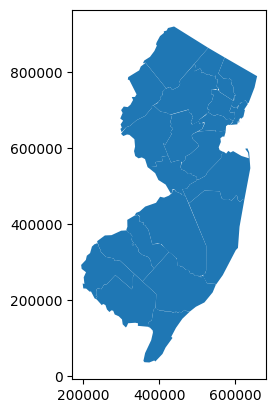

In [ ]:
a=gpd.read_file('njC.geojson')
a.plot() #works fine in gpd

In [ ]:
with open('test.geojson', 'w') as f:
    f.write(njC.to_json(to_wgs84=True))
!head test.geojson #proper coordinates now :)

34896

{"type": "FeatureCollection", "features": [{"id": "0", "type": "Feature", "properties": {"COUNTY": "ATLANTIC", "COUNTY_LAB": "Atlantic County", "POP2010": 274549, "POPDEN2010": 450}, "geometry": {"type": "Polygon", "coordinates": [[[-74.67437233383701, 39.68857583767599], [-74.65978698432146, 39.667804778342834], [-74.65480134348013, 39.62684603430755], [-74.63415270508177, 39.6280730548772], [-74.62871784430699, 39.62009466047849], [-74.62102776040155, 39.62669103058673], [-74.57665479765272, 39.598596339071094], [-74.55390171009437, 39.59840608774667], [-74.5397012356475, 39.57498782365419], [-74.51479266834865, 39.57400207302361], [-74.49305202100206, 39.5556268863461], [-74.46299654876402, 39.55644435619163], [-74.45608977699081, 39.54726920980147], [-74.44650946221375, 39.5590071407023], [-74.43750000713119, 39.54119765103669], [-74.43802029348575, 39.55382835677089], [-74.41754424326376, 39.55735463165842], [-74.38079627108975, 39.498536853134375], [-74.30950883546215, 39.5032735

In [ ]:
import folium as f
map = f.Map()
f.GeoJson('test.geojson').add_to(map)
map

### geocoding

https://automating-gis-processes.github.io/CSC/notebooks/L3/Geocoding_in_Geopandas.html

In [ ]:
df=pd.read_csv('https://github.com/theaok/data/raw/main/addresses.txt',sep=';')
df=df[0:5]
df

,id,addr
0,1000,"Itämerenkatu 14, 00101 Helsinki, Finland"
1,1001,"Kampinkuja 1, 00100 Helsinki, Finland"
2,1002,"Kaivokatu 8, 00101 Helsinki, Finland"
3,1003,"Hermannin rantatie 1, 00580 Helsinki, Finland"
4,1005,"Tyynenmerenkatu 9, 00220 Helsinki, Finland"


In [ ]:
from geopandas.tools import geocode

In [ ]:
#change adam to your name
geo = geocode(df['addr'], provider='nominatim', user_agent='car',timeout=2)
geo.head(2)

,geometry,address
0,POINT (24.91556 60.1632),"Ruoholahti, 14, Itämerenkatu, Ruoholahti, Läns..."
1,POINT (24.93166 60.16905),"Kamppi, 1, Kampinkuja, Kamppi, Eteläinen suurp..."


<Axes: >

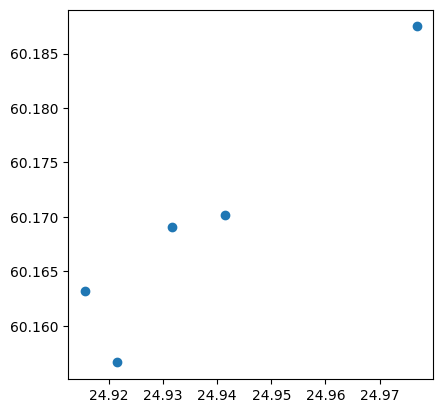

In [ ]:
geo.plot()

### map x y ( lat lon)

https://geopandas.org/en/stable/gallery/create_geopandas_from_pandas.html

In [ ]:
df = pd.DataFrame(
    {
        "City": ["Buenos Aires", "Brasilia", "Santiago", "Bogota", "Caracas"],
        "Country": ["Argentina", "Brazil", "Chile", "Colombia", "Venezuela"],
        "Latitude": [-34.58, -15.78, -33.45, 4.60, 10.48],
        "Longitude": [-58.66, -47.91, -70.66, -74.08, -66.86],
    }
)
df

,City,Country,Latitude,Longitude
0,Buenos Aires,Argentina,-34.58,-58.66
1,Brasilia,Brazil,-15.78,-47.91
2,Santiago,Chile,-33.45,-70.66
3,Bogota,Colombia,4.60,-74.08
4,Caracas,Venezuela,10.48,-66.86


In [ ]:
gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.Longitude, df.Latitude) #, crs="EPSG:4326"
)
#note the projection, may try with or without it: crs;
#if things map like in ocean or antarctica, email listserv

<Axes: >

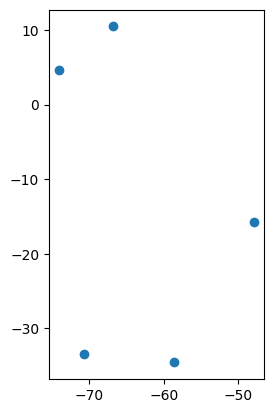

In [ ]:
gdf.plot()

###  subset shapefile

In [ ]:
!wget -q -O us.zip https://github.com/theaok/data/raw/main/cb_2018_us_state_500k.zip
zip_ref = zipfile.ZipFile('us.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping

<Axes: >

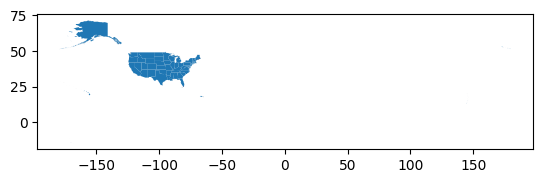

In [ ]:
us=gpd.read_file('cb_2018_us_state_500k.shp')
us.plot()

<Axes: >

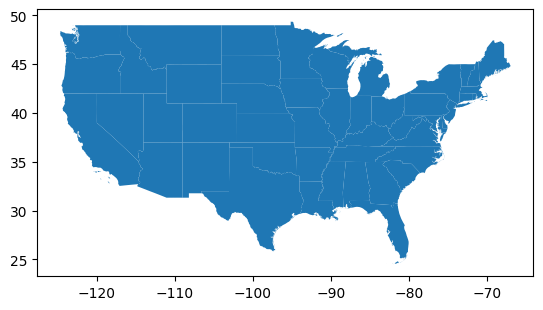

In [ ]:
cont = us[~us['NAME'].isin(['Alaska', 'Hawaii', 'Puerto Rico','American Samoa','United States Virgin Islands','Guam','Commonwealth of the Northern Mariana Islands'])]
cont.plot()

or just google for what you want; even possibly with inset :)

https://www.google.com/search?client=firefox-b-1-d&q=uss+hapefile+alaska+perto+rico+inset

or:

https://www.google.com/search?client=firefox-b-1-d&q=coniguous+us+states+shapefgile

eg:
https://cartographyvectors.com/map/1201-contiguous-us-with-states

### aggregate data: groupby+agg

make sure stuff matches 1:1, not 1:many, eg when you merge uni to counties, thats many:1, many uni per 1 county, need to aggregate first to a summary stats like sum!!!

In [ ]:
! wget -q -O nj-counties.zip https://docs.google.com/uc?id=1xJDhcRCkgv7k4tNCa72Oog5bohV6dTB2&export=download
zip_ref = zipfile.ZipFile('nj-counties.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping
njC0=gpd.read_file('nj_counties.shp') #load the shapefile with gpd as njC

In [ ]:
!wget -q -O col.zip  https://docs.google.com/uc?id=1bb9KES6QDE7cleE4L38yQ7939LlXUHB5&export=download
zip_ref = zipfile.ZipFile('col.zip', 'r');zip_ref.extractall(); zip_ref.close()

col0 = gpd.read_file('2007_11_30_NJ_COLL_UNIV_njsp.shp')
col0.dtypes
col0.head(3)

,0
ID,object
METLNKID,object
FEATTYPE,object
SECCLASS,object
NAME,object
AREA,object
PHONE,object
ADDRESS,object
ADDRESS2,object
CITY,object


,ID,METLNKID,FEATTYPE,SECCLASS,NAME,AREA,PHONE,ADDRESS,ADDRESS2,CITY,...,X,Y,ST_VENDOR,ST_VERSION,GEOPREC,PHONELOC,QC_QA,DEGREE,ENROLL,geometry
0,10273936,None,POINT,UNCLASSIFIED,RAMAPO COLLEGE OF NEW JERSEY,201,684-7500,505 RAMAPO VALLEY RD,None,MAHWAH,...,-74.177826,41.082642,NAVTEQ,2006Q4,BLOCKFACE,None,None,MASTER'S DEGREE,5538,POINT (580936.143 819465.262)
1,10273934,None,POINT,UNCLASSIFIED,NEW BRUNSWICK THEOLOGICAL SEMINARY,732,247-5241,17 SEMINARY PL,None,NEW BRUNSWICK,...,-74.448814,40.501346,NAVTEQ,2006Q4,BLOCKFACE,None,None,DOCTOR'S DEGREE,203,POINT (506358.894 607539.257)
2,10273932,None,POINT,UNCLASSIFIED,MONMOUTH UNIVERSITY,732,571-3400,400 CEDAR AVE,None,WEST LONG BRANCH,...,-74.003765,40.281505,NAVTEQ,2006Q4,BLOCKFACE,None,None,POST-MASTER'S CERTIFICATE,6351,POINT (630565.964 527840.459)


In [ ]:
col=col0[['COUNTY','NAME','ENROLL']]
#col
col.ENROLL=col.ENROLL.astype(float)
col.sort_values(by='COUNTY',inplace=True)
col

/tmp/ipython-input-4072875663.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  col.ENROLL=col.ENROLL.astype(float)
/tmp/ipython-input-4072875663.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  col.sort_values(by='COUNTY',inplace=True)


,COUNTY,NAME,ENROLL
36,ATLANTIC,ATLANTIC CAPE COMMUNITY COLLEGE,6845.0
25,ATLANTIC,THE RICHARD STOCKTON COLLEGE OF NEW JERSEY,7035.0
0,BERGEN,RAMAPO COLLEGE OF NEW JERSEY,5538.0
33,BERGEN,FAIRLEIGH DICKINSON UNIVERSITY - METROPOLITAN ...,8237.0
37,BERGEN,BERGEN COMMUNITY COLLEGE,14762.0
...,...,...,...
62,SUSSEX,SUSSEX COUNTY COMMUNITY COLLEGE,3461.0
13,UNION,UNION COUNTY COLLEGE,10976.0
47,UNION,KEAN UNIVERSITY,12958.0
14,WARREN,CENTENARY COLLEGE,2460.0


In [ ]:
colAgg=col.groupby('COUNTY').agg('sum')
colAgg
6845+7035==13880  #double check from previous table

#then can merge and map :)

,NAME,ENROLL
COUNTY,,
ATLANTIC,ATLANTIC CAPE COMMUNITY COLLEGETHE RICHARD STO...,13880.0
BERGEN,RAMAPO COLLEGE OF NEW JERSEYFAIRLEIGH DICKINSO...,30343.0
BURLINGTON,BURLINGTON COUNTY COLLEGE,7888.0
CAMDEN,UNIVERSITY OF MEDICINE AND DENTISTRY OF NEW JE...,20058.0
CUMBERLAND,CUMBERLAND COUNTY COLLEGE,3260.0
ESSEX,ESSEX COUNTY COLLEGENEW JERSEY INSTITUTE OF TE...,65569.0
GLOUCESTER,ROWAN UNIVERSITYGLOUCESTER COUNTY COLLEGE,15784.0
HUDSON,SAINT PETERS COLLEGESTEVENS INSTITUTE OF TECHN...,22915.0
MERCER,THE COLLEGE OF NEW JERSEYRIDER UNIVERSITYPRINC...,39979.0


True

### standardize and finer resolution

In [ ]:
! wget -q -O nj-counties.zip https://docs.google.com/uc?id=1xJDhcRCkgv7k4tNCa72Oog5bohV6dTB2&export=download
zip_ref = zipfile.ZipFile('nj-counties.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping
njC0=gpd.read_file('nj_counties.shp') #load the shapefile with gpd as njC
njC=njC0[['COUNTY','COUNTY_LAB','POP2010','POPDEN2010','SQ_MILES','geometry']]

<Axes: >

[]

[]

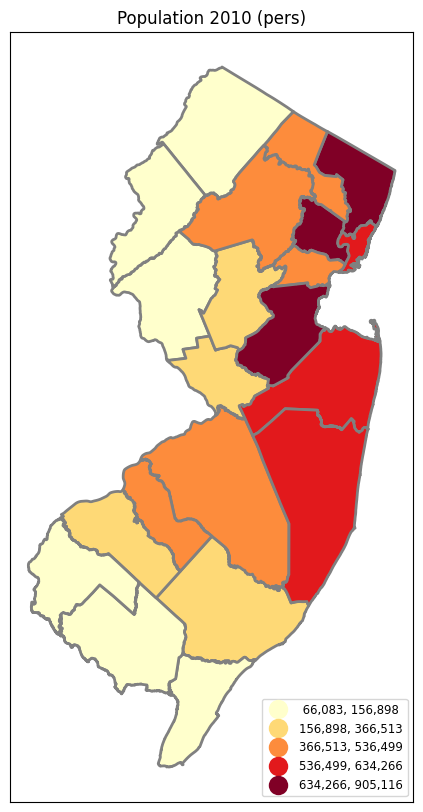

In [ ]:
fig, ax = plt.subplots(1, figsize=(6,10))
njC.plot(ax=ax,column='POP2010',legend=True,cmap='YlOrRd',scheme='natural_breaks',k=5,
         edgecolor='grey',linewidth=2,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4}) #
ax.title.set_text("Population 2010 (pers)")
ax.set_xticks([]); ax.set_yticks([])

In [ ]:
njC['popDen10']=njC.POP2010/njC.SQ_MILES

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


<Axes: >

[]

[]

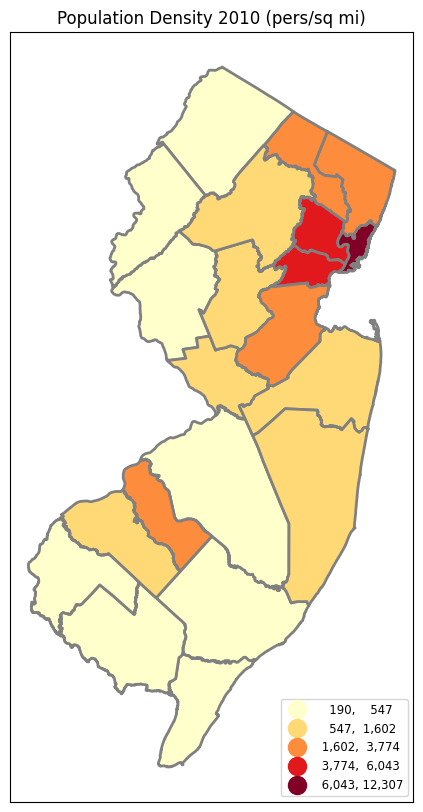

In [ ]:
fig, ax = plt.subplots(1, figsize=(6,10))
njC.plot(ax=ax,column='popDen10',legend=True,cmap='YlOrRd',scheme='natural_breaks',k=5,
         edgecolor='grey',linewidth=2,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4}) #
ax.title.set_text("Population Density 2010 (pers/sq mi)")
ax.set_xticks([]); ax.set_yticks([])

In [ ]:
njM0=gpd.read_file('nj_munis.shp')
njM=njM0[['COUNTY','POP2010','POPDEN2010','SQ_MILES','geometry']]

<Axes: >

[]

[]

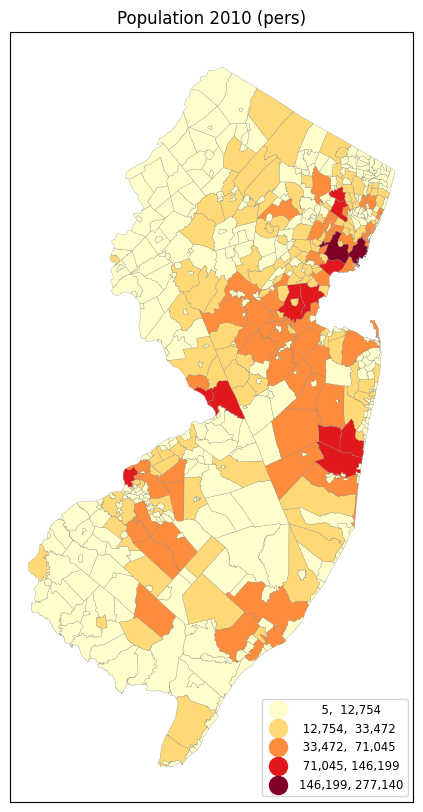

In [ ]:
fig, ax = plt.subplots(1, figsize=(6,10))
njM.plot(ax=ax,column='POP2010',legend=True,cmap='YlOrRd',scheme='natural_breaks',k=5,
         edgecolor='grey',linewidth=0.2,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4}) #
ax.title.set_text("Population 2010 (pers)")
ax.set_xticks([]); ax.set_yticks([])

### side-by-side and overlay

<Axes: >

[]

[]

<Axes: >

[]

[]

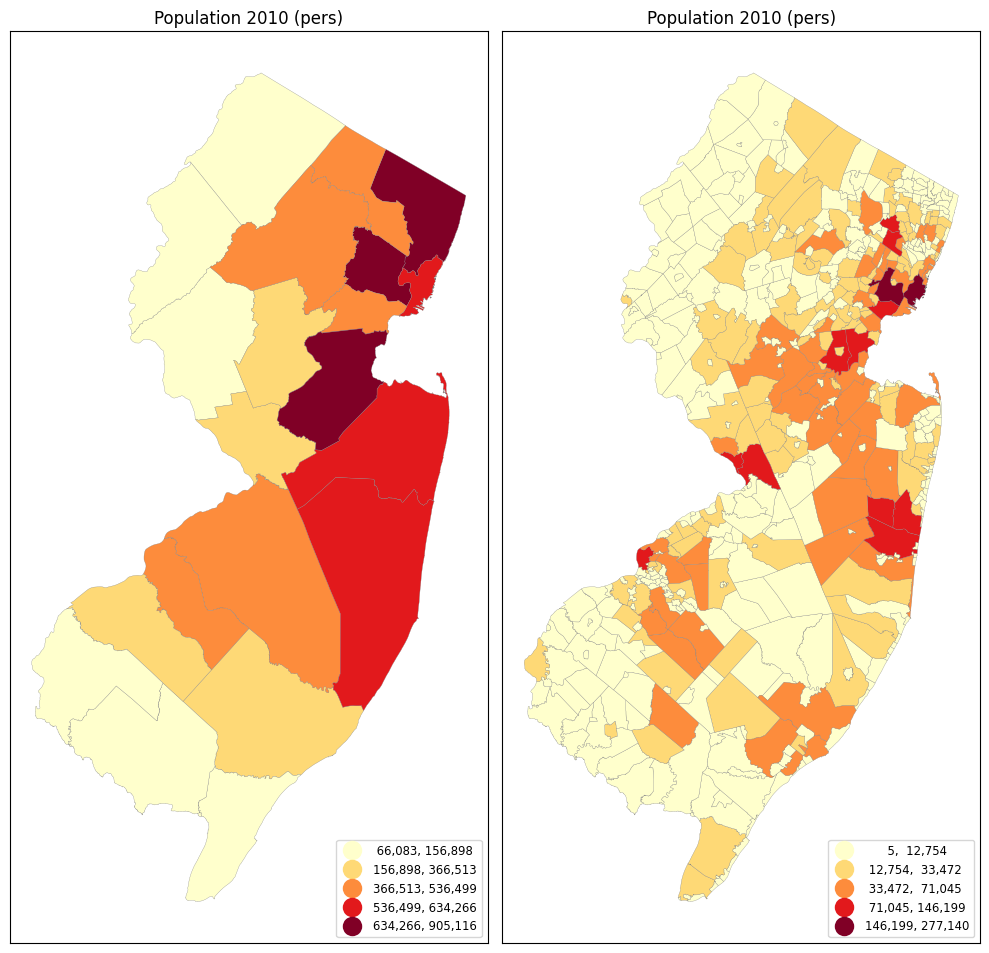

In [ ]:
#side-by-side: subplots 1row,2col; then just axs[0] and axs[1]
fig, axs = plt.subplots(1,2, figsize=(10,10),sharey=True, tight_layout=True)
njC.plot(ax=axs[0],column='POP2010',legend=True,cmap='YlOrRd',scheme='natural_breaks',k=5,
         edgecolor='grey',linewidth=0.2,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4}) #
axs[0].title.set_text("Population 2010 (pers)")
axs[0].set_xticks([]); axs[0].set_yticks([])

njM.plot(ax=axs[1],column='POP2010',legend=True,cmap='YlOrRd',scheme='natural_breaks',k=5,
         edgecolor='grey',linewidth=0.2,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4}) #
axs[1].title.set_text("Population 2010 (pers)")
axs[1].set_xticks([]); axs[1].set_yticks([])

<Axes: >

<Axes: >

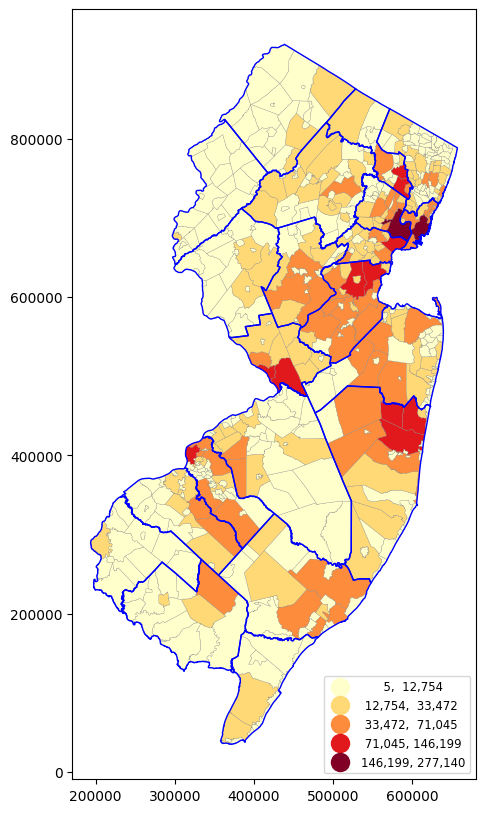

In [ ]:
#overlay: just keep adding on the same ax
fig, ax = plt.subplots(1, figsize=(6,10))
njM.plot(ax=ax,column='POP2010',legend=True,cmap='YlOrRd',scheme='natural_breaks',k=5,
         edgecolor='grey',linewidth=0.2,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4})
njC.plot(ax=ax,edgecolor='blue',linewidth=1, facecolor="none") #alpha=0.1)

to overlay 2 thematic polygon layers, probably cleanest to just have 2 cat eg yes/no for the overlay, or maybe max 3 cat say lo, med, and hi



In [ ]:
njC.COUNTY #say we want to overlay camden and cumberland

,COUNTY
0,ATLANTIC
1,BERGEN
2,BURLINGTON
3,CAMDEN
4,CAPE MAY
5,CUMBERLAND
6,ESSEX
7,GLOUCESTER
8,HUDSON
9,HUNTERDON


In [ ]:
#first, subset to some interesting area, and then overlay that
njC_cam_cum=njC.query("COUNTY=='CAMDEN' | COUNTY=='CUMBERLAND'")

<>:12: SyntaxWarning: invalid escape sequence '\ '
<>:12: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipython-input-3959040549.py:12: SyntaxWarning: invalid escape sequence '\ '
  \   - back diagonal


<Axes: >

<Axes: >

'\n/   - diagonal hatching\n\\   - back diagonal\n|   - vertical\n-   - horizontal\n+   - crossed\nx   - crossed diagonal\no   - small circle\nO   - large circle\n.   - dots\n*   - stars\n'

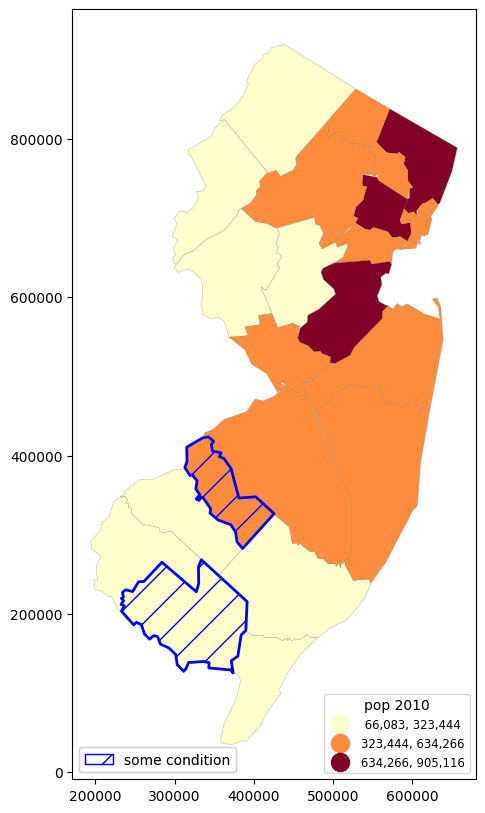

In [ ]:
fig, ax = plt.subplots(1, figsize=(6,10))
njC.plot(ax=ax,column='POP2010',legend=True,cmap='YlOrRd',scheme='natural_breaks',k=3,
         edgecolor='grey',linewidth=0.2,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4})

#just like subset and hash or dot
#njC_cam_cum.plot(ax=ax,edgecolor='blue',linewidth=2, facecolor="none",alpha=1)
njC_cam_cum.plot(ax=ax,edgecolor='blue',linewidth=2, facecolor="none",alpha=1,hatch='/')
#njC_cam_cum.plot(ax=ax,edgecolor='blue',linewidth=2, facecolor="none",alpha=1,hatch='///')
'''
/   - diagonal hatching
\   - back diagonal
|   - vertical
-   - horizontal
+   - crossed
x   - crossed diagonal
o   - small circle
O   - large circle
.   - dots
*   - stars
'''

l1 = ax.get_legend()
l1.set_title('''pop 2010''')

import matplotlib.patches as mpatches

bluePatch = mpatches.Patch(edgecolor='blue', facecolor='none',
                     hatch='/', label=r'some condition')

l2=plt.legend(handles=[bluePatch],loc='lower left')

ax.add_artist(l2)
ax.add_artist(l1)


#njC.plot(ax=ax,edgecolor='blue',linewidth=1, facecolor="none") #alpha=0.1)

<Axes: >

<Axes: >

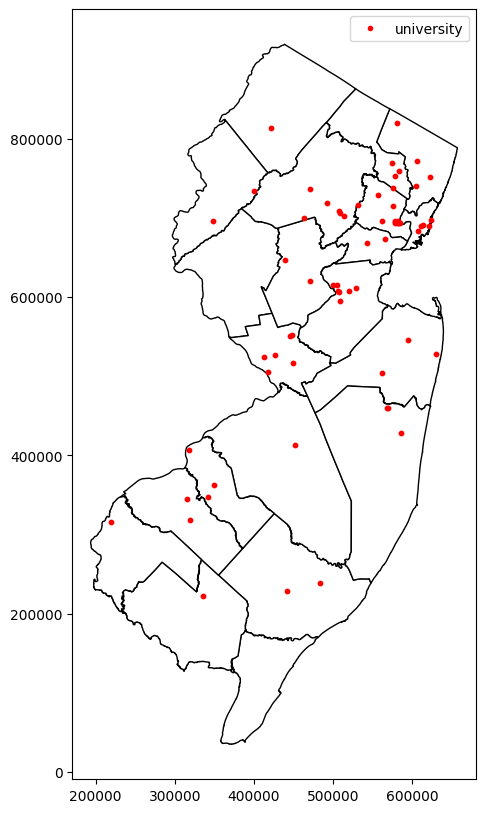

In [ ]:
#overlay with points, same as earlier under sec: dive into...
!wget -q -O col.zip  https://docs.google.com/uc?id=1bb9KES6QDE7cleE4L38yQ7939LlXUHB5&export=download
zip_ref = zipfile.ZipFile('col.zip', 'r');zip_ref.extractall(); zip_ref.close()

col = gpd.read_file('2007_11_30_NJ_COLL_UNIV_njsp.shp')

#overlay: just use plot fn twice
fig, ax = plt.subplots(1, figsize=(6,10))
njC.plot(ax=ax, color='white', edgecolor='black',linewidth=1)
col.plot(ax=ax, marker='o', color='red', markersize=10,legend=True)
#col.plot(column='enr',markersize=50,legend=True,cmap='RdYlGn_r',scheme='QUANTILES',k=5,ax=ax)
#ax.set_title('Watersheds by area ($mi^2$)')

#custom legend
#https://stackoverflow.com/questions/39500265/how-to-manually-create-a-legend
#import matplotlib.patches as mpatches
#red_patch = mpatches.Patch(color='red', label='The red data')
from matplotlib.lines import Line2D
point = Line2D([0], [0], label='university', marker='o', markersize=3,
         markeredgecolor='r', markerfacecolor='r', linestyle='')
plt.legend(handles=[point])

<Axes: >

<Axes: >

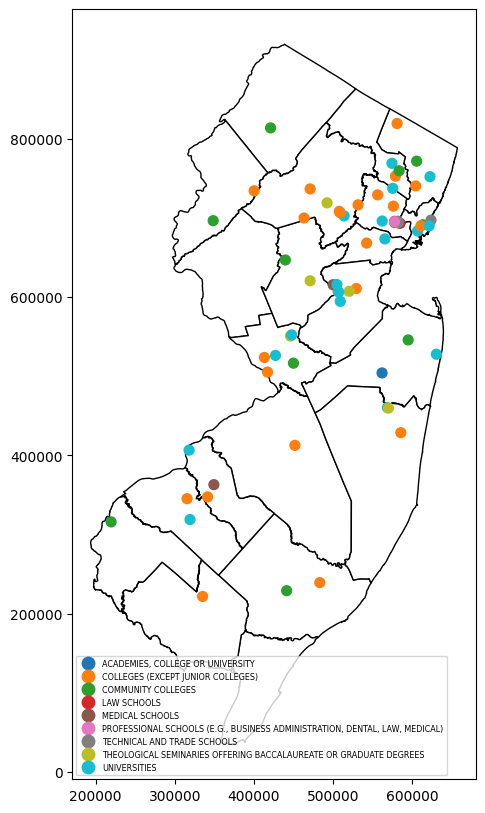

In [ ]:
#from pandas.core.interchange.dataframe_protocol import Column
!wget -q -O col.zip  https://docs.google.com/uc?id=1bb9KES6QDE7cleE4L38yQ7939LlXUHB5&export=download
zip_ref = zipfile.ZipFile('col.zip', 'r');zip_ref.extractall(); zip_ref.close()

col = gpd.read_file('2007_11_30_NJ_COLL_UNIV_njsp.shp')

#overlay: just use plot fn twice
fig, ax = plt.subplots(1, figsize=(6,10))
njC.plot(ax=ax, color='white', edgecolor='black',linewidth=1)
col.plot(ax=ax, marker='o',markersize=50,legend=True,column='NAICSDESCR',
         legend_kwds= {
        'loc':'lower left','title_fontsize':'medium','fontsize':'xx-small','markerscale':1.0})
#ok first stab, but too cluttered; group into like say max 5 cats

#### add to canvas anything: turn anything into img eg pd styler

In [ ]:
%%capture
!pip install imgkit
!sudo apt-get install wkhtmltopdf
import imgkit

In [ ]:
! wget -q -O nj-counties.zip https://docs.google.com/uc?id=1xJDhcRCkgv7k4tNCa72Oog5bohV6dTB2&export=download
zip_ref = zipfile.ZipFile('nj-counties.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping
njC0=gpd.read_file('nj_counties.shp') #load the shapefile with gpd as njC

njC=njC0[['COUNTY','COUNTY_LAB','POP2010','POPDEN2010','geometry']]


In [ ]:
njCs = njC[['COUNTY','POP2010']].sort_values(by='POP2010', ascending=False)
sty = njCs.style.background_gradient(cmap='YlOrRd')
sty

,COUNTY,POP2010
1,BERGEN,905116
20,MIDDLESEX,809858
6,ESSEX,783969
8,HUDSON,634266
11,MONMOUTH,630380
12,OCEAN,576567
17,UNION,536499
3,CAMDEN,513657
13,PASSAIC,501226
19,MORRIS,492276


QStandardPaths: XDG_RUNTIME_DIR not set, defaulting to '/tmp/runtime-root'
Loading page (1/2)
Rendering (2/2)                                                    
Done                                                               


True

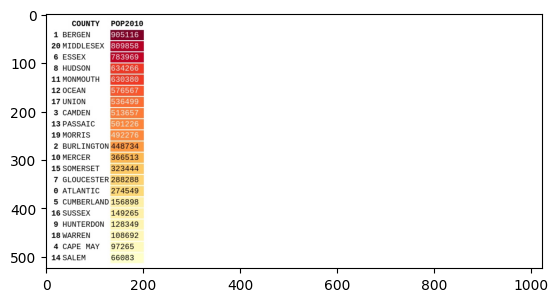

In [ ]:
imgkit.from_string(sty.to_html(), 'sty.jpg')

import matplotlib.image as mpimg
img = mpimg.imread('sty.jpg')
plt.imshow(img)

<Axes: >

[]

[]

[]

[]

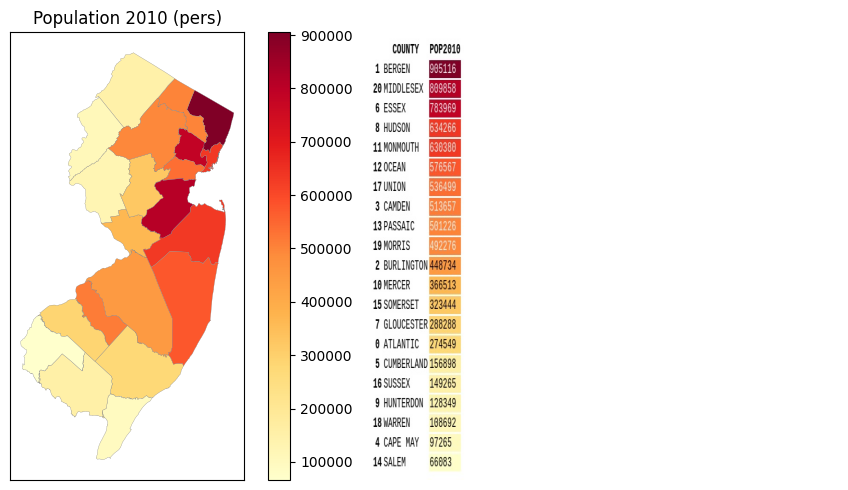

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(10,5),tight_layout=True)
njC.plot(ax=axs[0],column='POP2010',legend=True,cmap='YlOrRd',#scheme='natural_breaks',k=5,
         edgecolor='grey',linewidth=0.2,
         #legend_kwds= {"fmt": "{:,.0f}", 'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4}
         ) #
axs[0].title.set_text("Population 2010 (pers)")
axs[0].set_xticks([]); axs[0].set_yticks([])

axs[1].imshow(img,aspect='auto') #,  extent=[0,1,0,1]  aspect=3.5
axs[1].set_axis_off()
axs[1].set_xticks([]); axs[1].set_yticks([])

### centroids thematic maps

In [ ]:
njP = njC.copy()

njP["geometry"] = njP["geometry"].centroid

In [ ]:
njP.head(3)

,COUNTY,COUNTY_LAB,POP2010,POPDEN2010,geometry
0,ATLANTIC,Atlantic County,274549,450,POINT (446845.671 234718.679)
1,BERGEN,Bergen County,905116,3774,POINT (608674.972 775344.901)
2,BURLINGTON,Burlington County,448734,547,POINT (445015.1 380378.991)


<Axes: >

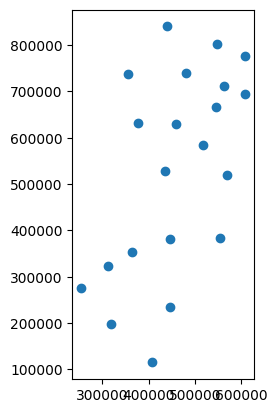

In [ ]:
njP.plot()

<Axes: >

[]

[]

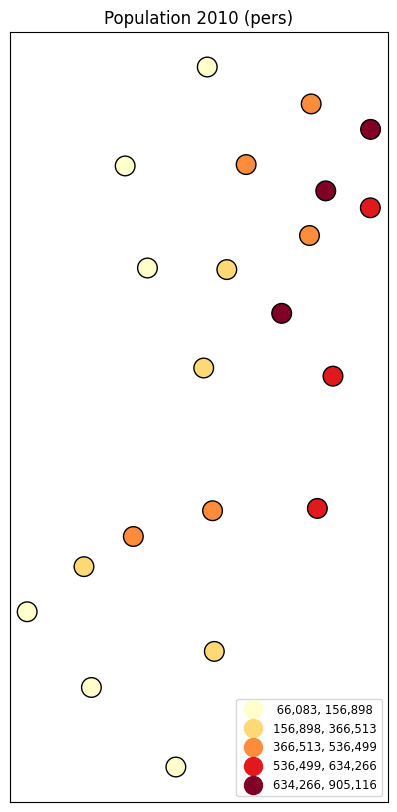

In [ ]:
fig, ax = plt.subplots(1, figsize=(6,10))
njP.plot(ax=ax,column='POP2010',legend=True,cmap='YlOrRd',scheme='natural_breaks',k=5,
         edgecolor='black',linewidth=1,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4},
         markersize = 200) #
ax.title.set_text("Population 2010 (pers)")
ax.set_xticks([]); ax.set_yticks([])

<Axes: >

<Axes: >

[]

[]

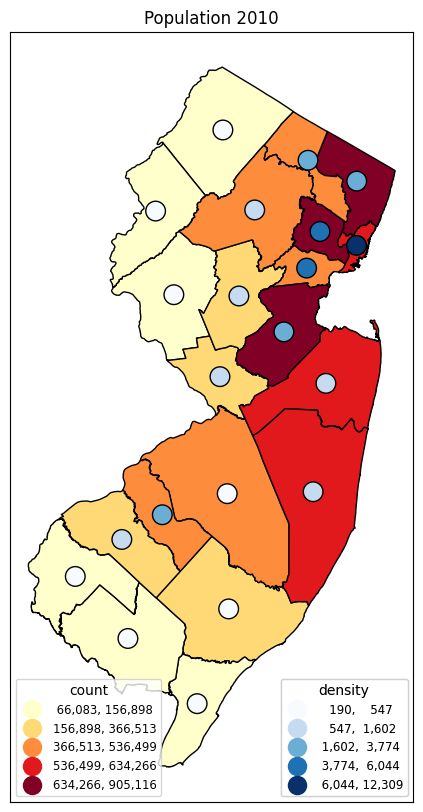

In [ ]:
fig, ax = plt.subplots(1, figsize=(6,10))
njC.plot(ax=ax,column='POP2010',legend=True,cmap='YlOrRd',scheme='natural_breaks',k=5,
         edgecolor='black',linewidth=1,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower left','title_fontsize':'medium','fontsize':'small','markerscale':1.4})

l1 = ax.get_legend()
l1.set_title('''count''')

njP.plot(ax=ax,column='POPDEN2010',legend=True,cmap='Blues',scheme='natural_breaks',k=5,
         edgecolor='black',linewidth=1,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4},
         markersize = 200) #

ax.title.set_text("Population 2010")
ax.set_xticks([]); ax.set_yticks([])

l2 = ax.get_legend()
l2.set_title('''density''')



ax.add_artist(l2)
ax.add_artist(l1)

### edgecolors

<Axes: >

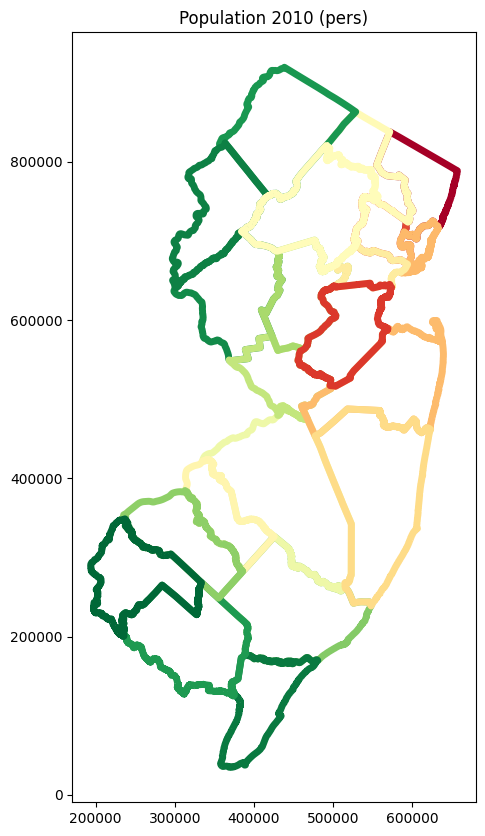

In [ ]:
#https://colab.research.google.com/github/hbeck118/GIS/blob/main/ps3_final.ipynb#scrollTo=Vlg-X8y1_pQW&line=21&uniqifier=1
#TODO get legend working as in above reference
import matplotlib.colors as mcolors

#TODO: simplify
norm = mcolors.Normalize(vmin=njC['POP2010'].min(),
                         vmax=njC['POP2010'].max())
edgecolors = plt.cm.RdYlGn_r(norm(njC['POP2010'].values))

fig, ax = plt.subplots(1, figsize=(6,10))
njC.plot(ax=ax,edgecolor=edgecolors,alpha=1, linewidth=5, facecolor="none") #
ax.title.set_text("Population 2010 (pers)")
#the limitation is edges overlap,and having them transparent doesnt help much;
#but can see the other color a tincy bit around the line

### annotate

Text(446845.6710119825, 234718.67854471222, 'ATLANTIC')

Text(608674.9722903798, 775344.9010704905, 'BERGEN')

Text(445015.10017129, 380378.9908087645, 'BURLINGTON')

Text(362977.140254135, 353705.812773536, 'CAMDEN')

Text(407013.1101691078, 114992.23820242906, 'CAPE MAY')

...

Text(439541.23874521523, 839964.6338105244, 'SUSSEX')

Text(545391.2858900087, 665430.0582508749, 'UNION')

Text(354515.98946147866, 737506.369618912, 'WARREN')

Text(479789.7234039994, 738913.4075906109, 'MORRIS')

Text(516625.77448488685, 584830.6357102671, 'MIDDLESEX')

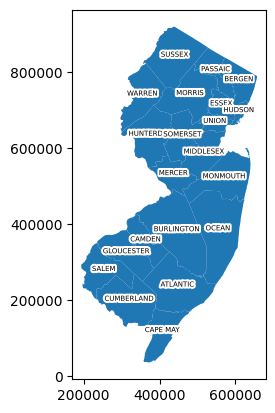

In [ ]:
#u/a labels: basic and useful thing to do
from matplotlib.patheffects import withStroke
ax=njC.plot() #https://stackoverflow.com/questions/38899190/geopandas-label-polygons
for x, y, label in zip(njP.geometry.x, njP.geometry.y, njP.COUNTY):
    ax.annotate(label, xy=(x, y),horizontalalignment='center',
    fontsize=5,color='black', #fontweight='bold',
    path_effects=[withStroke(linewidth=3, foreground='white')]) #ytext=(3, 3), textcoords="offset points"

<Axes: >

Text(400000, 800000, 'blah')

Text(400000, 130000, 'cape may')

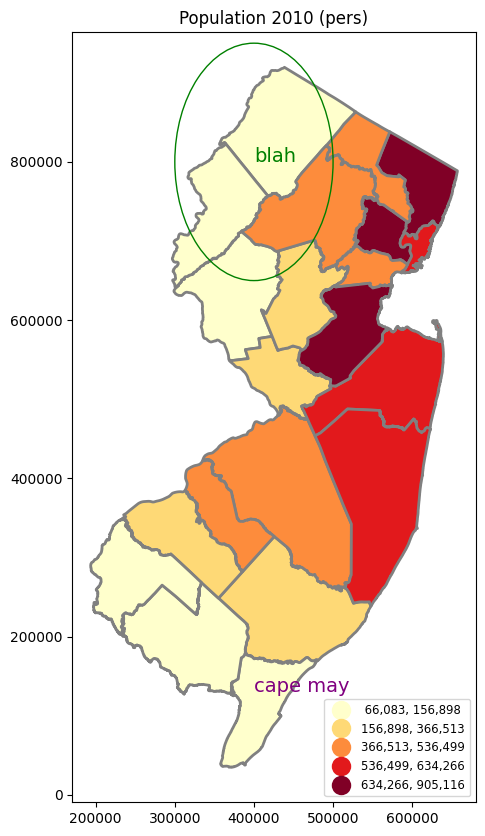

In [ ]:
fig, ax = plt.subplots(1, figsize=(6,10))
njC.plot(ax=ax,column='POP2010',legend=True,cmap='YlOrRd',scheme='natural_breaks',k=5,
         edgecolor='grey',linewidth=2,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4}) #
ax.title.set_text("Population 2010 (pers)")

ax.text(400000, 800000, r'blah', fontsize=14, color='green')
ax.text(400000, 130000, r'cape may', fontsize=14, color='purple')

from matplotlib.patches import Ellipse
e1 = Ellipse(xy=(400000, 800000), width=200000, height=300000, edgecolor='g', fc='None', lw=1)
ax.add_patch(e1)

<Axes: >

Text(335000, 350000, '❤')

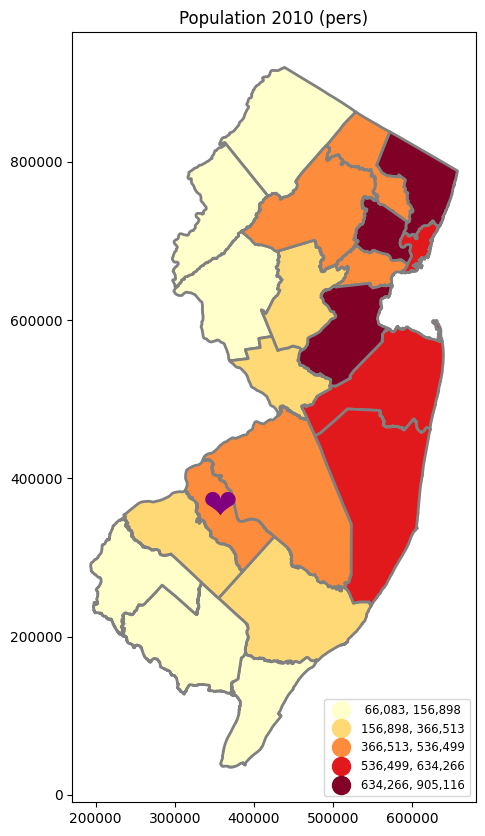

In [ ]:
#emoji
fig, ax = plt.subplots(1, figsize=(6,10))
njC.plot(ax=ax,column='POP2010',legend=True,cmap='YlOrRd',scheme='natural_breaks',k=5,
         edgecolor='grey',linewidth=2,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4}) #
ax.title.set_text("Population 2010 (pers)")

ax.text(335000, 350000, r'❤', fontsize=30, color='purple')
#ax.text(400000, 800000, r'👽', fontsize=70,color='red') #can just google emoji, eg https://www.google.com/search?q=emoji+alien%27&rlz=1CAHWSA_enUS1125US1125&oq=emoji+alien%27&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIHCAEQABiABDIHCAIQABiABDIHCAMQABiABDIHCAQQABiABDIHCAUQABiABDIHCAYQABiABDIICAcQABgWGB4yCAgIEAAYFhgeMggICRAAGBYYHtIBCDQ2NzZqMGo3qAIAsAIA&sourceid=chrome&ie=UTF-8
#some more fancy ones like alien may not render

more info on annotations eg how to add arrow and format annotations:
https://colab.research.google.com/github/theaok/vis/blob/main/all.ipynb#scrollTo=q00k6rAZ8tXo

### basemap (contextily)

https://geopandas.org/en/stable/gallery/plotting_basemap_background.html

they change quite a bit options and basemaps  https://contextily.readthedocs.io/

gallery: https://xyzservices.readthedocs.io/en/stable/gallery.html
 (most dont seem to work)
<br>for interactive mapping (zoom, move, popup) we will use folium/leaflet

In [ ]:
%%capture
! pip install contextily --upgrade
import contextily as cx
#cx.providers

In [ ]:
%%capture
###may break! comment out capture to see output, note just this cell is like 3mb!!

#njC = njC.to_crs(epsg=3857)
ax = njC.plot(figsize=(10, 20),facecolor='none',lw=2 , edgecolor='red') #alpha=0.5  zoom=12
#cx.add_basemap(ax,crs=njC.crs,source=cx.providers.USGS.USTopo)
#cx.add_basemap(ax,crs=njC.crs,source=cx.providers.OpenStreetMap.Mapnik)
cx.add_basemap(ax,crs=njC.crs,source=cx.providers.OpenTopoMap)
#cx.add_basemap(ax,crs=njC.crs, source=cx.providers.CartoDB.PositronNoLabels)
#cx.add_basemap(ax,crs=njC.crs, source=cx.providers.CartoDB.Voyager)
#cx.add_basemap(ax,crs=njC.crs, source=cx.providers.CartoDB.VoyagerNoLabels)
ax.set_axis_off()

### interactive and heat maps [skip]

https://geopandas.org/en/stable/docs/user_guide/interactive_mapping.html

https://nbviewer.org/gist/perrygeo/c426355e40037c452434 (heatmaps)

<br>we will use folium/leaflet later instead

### [*] dissolve

In [ ]:
!wget -q -O IND.zip https://github.com/theaok/data/raw/main/GIS-INDIA-MAP.zip
zip_ref = zipfile.ZipFile('IND.zip', 'r'); zip_ref.extractall(); zip_ref.close()
i = gpd.read_file('INDIA-MAP.shp')

In [ ]:
i.shape #wow its a lot

(693, 14)

<Axes: >

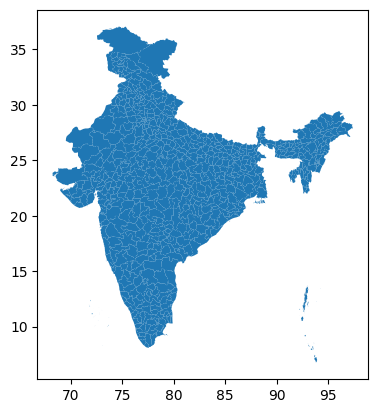

In [ ]:
i.plot()

In [ ]:
states = i.dissolve(by='statename',aggfunc='sum').reset_index()
states = states[['statename', 'distarea', 'totalpopul','totpopmale', 'totpopfema', 'geometry']]
states['statename'] = states['statename'].str.upper()

<Axes: >

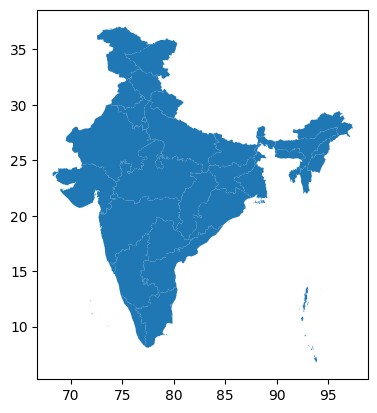

In [ ]:
states.plot()

### [*] projections

skip but if things get weird--mutated shapes, NJ in Pacific, then you have a projection problem

https://automating-gis-processes.github.io/CSC/notebooks/L2/projections.html

<Axes: >

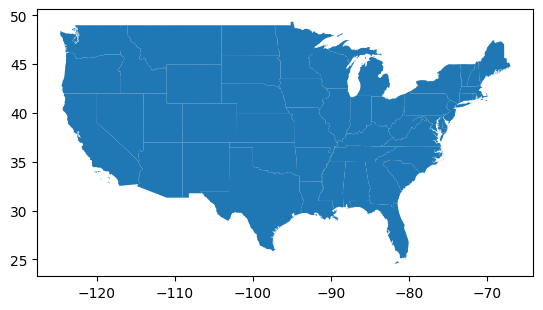

In [ ]:
!wget -q -O us.zip https://github.com/theaok/data/raw/main/cb_2018_us_state_500k.zip
zip_ref = zipfile.ZipFile('us.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping
us=gpd.read_file('cb_2018_us_state_500k.shp')
#us.plot()
cont = us[~us['NAME'].isin(['Alaska', 'Hawaii', 'Puerto Rico','American Samoa','United States Virgin Islands','Guam','Commonwealth of the Northern Mariana Islands'])]
cont.plot()

In [ ]:
cont.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

<Axes: >

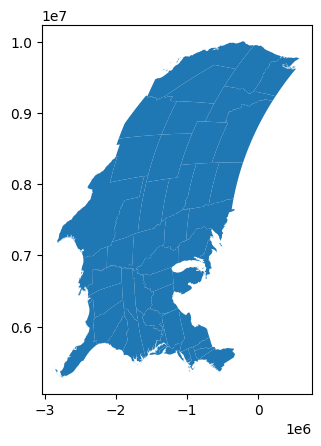

In [ ]:
cont.to_crs(epsg=3035).plot()

### [*] point in polygon/intersect, spatial join, nearest neighb

https://automating-gis-processes.github.io/CSC/notebooks/L4/Point-in-polygon.html

https://automating-gis-processes.github.io/CSC/notebooks/L4/spatial-join.html

https://automating-gis-processes.github.io/CSC/notebooks/L4/nearest-neighbour.html

## <font color='red'> \>will be updated from here\> </font>

# [oct9] other vis than gis/maps

it's gis--vis with maps, but do other vis too!

In [ ]:
import seaborn as sns
import plotly.express as px #a quick simple one
import plotly.graph_objects as go #can get convoluted
import numpy as np
import pandas as pd

In [ ]:
#note can get data straight from url, eg wiki
pd.read_html('https://en.wikipedia.org/wiki/List_of_U.S._states_and_territories_by_race/ethnicity',match="Mixed")[0].head(5) #for match use header of col; ideally unique; case may matter


,State,Total Population,White alone (NH),%,Black or African American alone (NH),%.1,Native American or Alaska Native alone (NH),%.2,Asian alone (NH),%.3,Pacific Islander alone (NH),%.4,Some Other Race alone (NH),%.5,Mixed Race or Multi-Racial (NH),%.6,Hispanic or Latino (any race),%.7
0,United States of America (50 states and D.C.),331449281,191697647,57.84%,39940338,12.05%,2251699,0.68%,19618719,5.92%,622018,0.19%,1689833,0.51%,13548983,4.09%,62080044,18.73%
1,"United States of America (50 states, D.C., an...",334735155,191722195,57.28%,39944624,11.93%,2252011,0.67%,19621465,5.86%,622109,0.19%,1692341,0.51%,13551323,4.05%,65329087,19.52%
2,Alabama,5024279,3171351,63.12%,1288159,25.64%,23119,0.46%,75918,1.51%,2612,0.05%,14455,0.29%,184618,3.67%,264047,5.26%
3,Alaska,733391,421758,57.51%,20731,2.83%,108838,14.84%,43449,5.92%,12455,1.70%,4575,0.62%,71761,9.78%,49824,6.79%
4,Arizona,7151502,3816547,53.37%,317161,4.43%,263930,3.69%,248837,3.48%,14323,0.20%,31611,0.44%,266840,3.73%,2192253,30.65%


In [ ]:

pd.read_html('https://en.wikipedia.org/wiki/List_of_towns_in_India_by_population',match="Type")[0].head(5)
#pd.read_html("https://en.wikipedia.org/wiki/Premier_League", match = "Position")[0].head(3)
#https://towardsdatascience.com/how-to-use-wikipedia-as-a-data-source-3dfea29e6539
#https://towardsdatascience.com/2-easy-ways-to-get-tables-from-a-website-with-pandas-b92fc835e741 some more ideas

#note if bunch of tables and or cant easily fetch teh right one, just fetch them all
#and then select the right one
#tables=pd.read_html("https://en.wikipedia.org/wiki/List_of_S%26P_500_companies")
#tables[0]
#tables[1]
#etc

,Town,State,Type,Population,Ref
0,Achhnera,Uttar Pradesh,N.P.,22781,NaN
1,Adalaj,Gujarat,C.T.,11957,NaN
2,Adoor,Kerala,M,29171,NaN
3,Adyar,Karnataka,C.T.,7034,NaN
4,Adra,West Bengal,C.T.,14956,NaN


In [ ]:
auto=pd.read_stata('https://docs.google.com/uc?id=1YpkQ-RgAQfB_4olxtbfRWnVmKwkXml5N&export=download')

In [ ]:
auto[:10].style.background_gradient(cmap='Greens') #RdYlGn #https://seaborn.pydata.org/tutorial/color_palettes.html

,make,price,mpg,rep78,headroom,trunk,weight,length,turn,displacement,gear_ratio,foreign
0,AMC Concord,4099,22,3.000000,2.500000,11,2930,186,40,121,3.580000,Domestic
1,AMC Pacer,4749,17,3.000000,3.000000,11,3350,173,40,258,2.530000,Domestic
2,AMC Spirit,3799,22,nan,3.000000,12,2640,168,35,121,3.080000,Domestic
3,Buick Century,4816,20,3.000000,4.500000,16,3250,196,40,196,2.930000,Domestic
4,Buick Electra,7827,15,4.000000,4.000000,20,4080,222,43,350,2.410000,Domestic
5,Buick LeSabre,5788,18,3.000000,4.000000,21,3670,218,43,231,2.730000,Domestic
6,Buick Opel,4453,26,nan,3.000000,10,2230,170,34,304,2.870000,Domestic
7,Buick Regal,5189,20,3.000000,2.000000,16,3280,200,42,196,2.930000,Domestic
8,Buick Riviera,10372,16,3.000000,3.500000,17,3880,207,43,231,2.930000,Domestic
9,Buick Skylark,4082,19,3.000000,3.500000,13,3400,200,42,231,3.080000,Domestic


<Axes: >

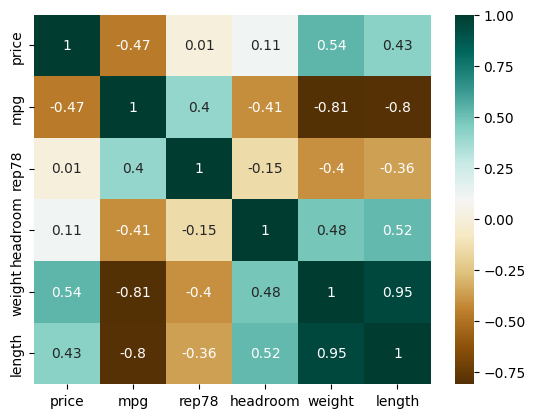

In [ ]:
sns.heatmap(auto[['price','mpg','rep78','headroom','weight','length']].corr().round(2),cmap="BrBG",annot=True) # RdYlGn love the colors!

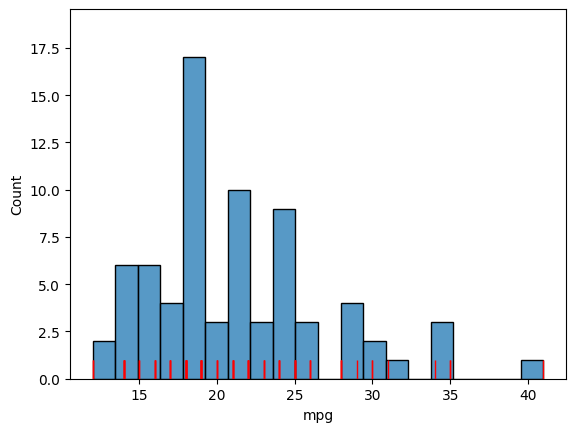

In [ ]:
#auto.mpg.hist(bins=20)
ax = sns.histplot(auto["mpg"], bins=20)
# Add rug on horizontal axis
sns.rugplot(auto["mpg"], height=0.05, color="red", ax=ax);

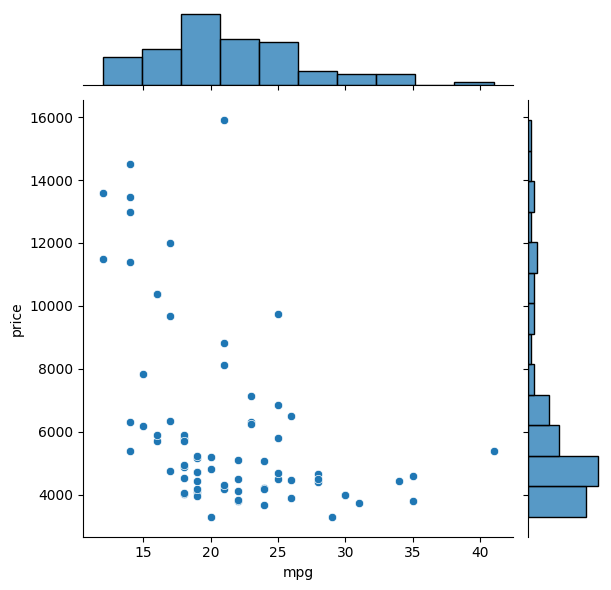

In [ ]:
sns.jointplot(x ='mpg', y ='price', data = auto)

In [ ]:
px.scatter(auto, x="weight", y="mpg", color="price",
                  hover_data=['make'],width=1000,height=600)

In [ ]:
#for cat data do crosstab, a visual version is density heatmap
px.density_heatmap(auto, x="rep78", y="headroom", marginal_x="histogram", marginal_y="histogram")

In [ ]:
df = px.data.gapminder().query("year == 2007")
px.treemap(df, path=[px.Constant("world"), 'continent', 'country'], values='pop',
                 color='lifeExp', hover_data=['iso_alpha'],
                  color_continuous_scale='RdBu',
                 color_continuous_midpoint=np.average(df['lifeExp'], weights=df['pop']))

# raster (picture)
remember slide from https://theaok.github.io/gisPy/data.pdf:

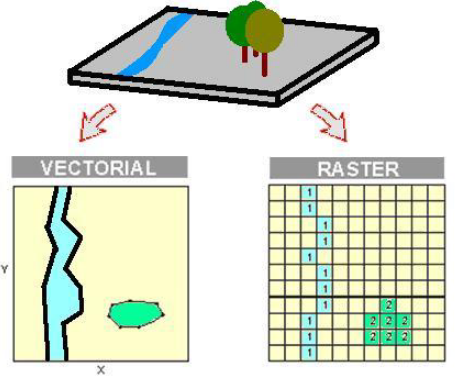

2 research applications: 1) over time: much of present can be explained with past; 2) compare across space<br>

redlining (vector) and contaminations: https://theaok.github.io/gis/gisGoodExampleOfFinalProject.pdf <br>
concrete in tx v nature in nj p43 https://drive.google.com/open?id=1Coj3CuwvzyoF2Rm_a0Fg5sSOXkTzuZlV

using rasterio lib

https://rasterio.readthedocs.io/en/latest/topics/plotting.html

https://geopandas.org/en/stable/gallery/geopandas_rasterio_sample.html

can get sat img straight to python, via API, eg

https://carpentries-incubator.github.io/geospatial-python/

https://sites.northwestern.edu/researchcomputing/2021/11/19/downloading-satellite-images-made-easy/

https://earthengine.google.com/timelapse/
very cool lets do default Columbia glacier 84 v 22 (pause; by hand)

and las vegas, same contrast, note less water, too (others:  urban growth, deforestation, etc)


check out Global Gridded Relative Deprivation Index (GRDI)
https://www.earthdata.nasa.gov/news/feature-articles/measuring-relative-poverty-deprivation-around-globe


but here we do images by hand: data from:

https://newjersey.maps.arcgis.com/apps/webappviewer/index.html?id=d13ac68c0d0f46139673824bbf19ad66
zoom in click on tile and copy link to (geo)tif

In [ ]:
!pip install rasterio
import rasterio
import matplotlib.pyplot as plt

In [ ]:
!wget -q -O tile145.tif https://njogis-imagery.s3-us-west-2.amazonaws.com/1930/cog/tile145.tif
src = rasterio.open("tile145.tif")
src.bounds #note bounds, these would be coords on x and y

BoundingBox(left=299560.2562470367, bottom=383483.5169948095, right=329077.91377203667, top=422472.6327158095)

In [ ]:
%%capture
#del capture above just to make notebook smaller
#it saves the code but not the output, that way the notebook isn't huge to load

fig, ax = plt.subplots(figsize=(20, 16))
ax.set_ylim([3000,2000]) #zoom onto waterfront
ax.set_xlim([2000,3000])
#ax.set_aspect(1/3)

ax.imshow(src.read(1)) #, aspect='auto',extent=[1500,5000,2000,20000]
#zorder=1,alpha=.6,interpolation='nearest'

#blurry, but still pretty awesome as for 1930!

In [ ]:
#250mb each! give it like 20sec to download
!wget -q -O D13C14-07.tif https://njogis-imagery.s3-us-west-2.amazonaws.com/2007/cog/D13C14.tif
src07 = rasterio.open("D13C14-07.tif")
!wget -q -O D13C14-20.tif https://njogis-imagery.s3.us-west-2.amazonaws.com/2020/cog/D13C14.tif
src20 = rasterio.open("D13C14-20.tif")
#src07.bounds

In [ ]:
%%capture
#del capture above just to make notebook smaller

fig, ax = plt.subplots(figsize=(20, 20))
#ax.set_ylabel('price')
#ax.set_xlabel('sdsa')
ax.set_ylim([5000,0])
ax.set_xlim([0,2000])
#ax.set_aspect(1/3)

ax.imshow(src07.read(1)) #, aspect='auto',extent=[1500,5000,2000,20000]
#zorder=1,alpha=.6,interpolation='nearest'

In [ ]:
%%capture
#del capture above just to make notebook smaller

fig, axs = plt.subplots(1, 2, sharey=True, tight_layout=True,figsize=(20, 20)) #1row2col
axs[0].imshow(src07.read(1))
axs[1].imshow(src20.read(1))
axs[0].set_ylim([5000,0])
axs[0].set_xlim([0,2000])
axs[1].set_ylim([5000,0])
axs[1].set_xlim([0,2000])
axs[0].set_title('2007 prison, ru stadium')
axs[1].set_title('2020 american water, hilton');

btw google street view has time too! eg:<br>
https://www.google.com/maps/place/401+Cooper+St,+Camden,+NJ+08102/@39.9471578,-75.1218999,3a,75y,14.87h,90t/data=!3m7!1e1!3m5!1sITXQj8a5aM3Xj91QOfu4Fw!2e0!6s%2F%2Fgeo0.ggpht.com%2Fcbk%3Fpanoid%3DITXQj8a5aM3Xj91QOfu4Fw%26output%3Dthumbnail%26cb_client%3Dsearch.gws-prod%2Fmaps%2Flocal-details-getcard.gps%26thumb%3D2%26w%3D86%26h%3D86%26yaw%3D14.87242%26pitch%3D0%26thumbfov%3D100!7i13312!8i6656!4m5!3m4!1s0x89c6c8f0e64a7e77:0xb5b160dc340e83ec!8m2!3d39.9473113!4d-75.121837

### [*] raster+vector (careful with crs)


In [ ]:
! wget -q -O nj-counties.zip https://docs.google.com/uc?id=1xJDhcRCkgv7k4tNCa72Oog5bohV6dTB2&export=download
zip_ref = zipfile.ZipFile('nj-counties.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping
njC0=gpd.read_file('nj_counties.shp') #
c=njC0[njC0.COUNTY=="CAMDEN"] #camden county

! wget -q -O tracts.zip https://github.com/theaok/data/raw/main/tl_2019_34_tract.zip
zip_ref = zipfile.ZipFile('tracts.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping
tracts=gpd.read_file('tl_2019_34_tract.shp')
tractsCam=tracts[tracts.COUNTYFP=='007'] #tracts in camden county

In [ ]:
%%capture
src.bounds #note extent (and in map's axes) x:300-330k y: 385k-420k
fig, ax = plt.subplots(figsize=(20, 10))
#ax.set_ylim([10000,1000]) #[3000,2000]
#ax.set_xlim([1000,10000]) #
#ax.set_aspect(1/3)
from rasterio.plot import show
rasterio.plot.show(src, ax=ax,)

In [ ]:
src.crs

CRS.from_wkt('LOCAL_CS["unnamed",UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]')

In [ ]:
c.crs #projected has 'weird corrds' in thousands

<Projected CRS: EPSG:3424>
Name: NAD83 / New Jersey (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - New Jersey - counties of Atlantic; Bergen; Burlington; Camden; Cape May; Cumberland; Essex; Gloucester; Hudson; Hunterdon; Mercer; Middlesex; Monmouth; Morris; Ocean; Passaic; Salem; Somerset; Sussex; Union; Warren.
- bounds: (-75.6, 38.87, -73.88, 41.36)
Coordinate Operation:
- name: SPCS83 New Jersey zone (US survey foot)
- method: Transverse Mercator
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

<Axes: >

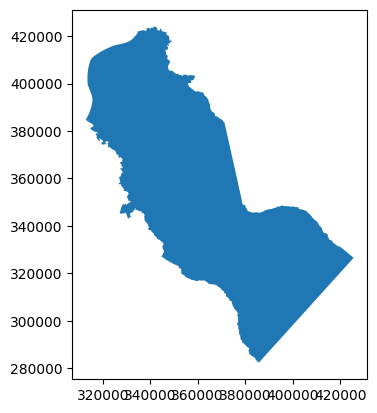

In [ ]:
c.plot() #our vector c coords matche raster src, so can map straight up

In [ ]:
%%capture
fig, ax = plt.subplots(figsize=(20, 10))
from rasterio.plot import show
rasterio.plot.show(src, ax=ax,) #, cmap="pink"
#ax.imshow(src.read(1))
c.plot(ax=ax,edgecolor='red',linewidth=1, facecolor="none")

In [ ]:
tractsCam.crs #geographic is lat -90 - 90 and lon -180 to 180

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

In [ ]:
tractsCam2 = tractsCam.to_crs(c.crs) #so have to transform
tractsCam3 = tractsCam.to_crs(src20.crs) #can user newer raster to transform vector too

In [ ]:
%%capture
fig, ax = plt.subplots(figsize=(20, 10))
ax.set_ylim([385000,420000]) #[3000,2000]
ax.set_xlim([310000,330000]) #

from rasterio.plot import show
rasterio.plot.show(src, ax=ax,) #, cmap="pink"
#ax.imshow(src.read(1))
tractsCam2.plot(ax=ax,edgecolor='white',linewidth=1, facecolor="none")

### for nat sci people

https://www.pyngl.ucar.edu/Examples/gallery.shtml

https://cdat.llnl.gov/gallery.html

## notes to myself

### fa24

### 2023

TODO if anything go thru gpd again esp as more features being added!
<br>

the whole course, geo dat sci: [oct2023 not super urgent; skimmed thru it already]
https://darribas.org/gds_course/content/home.html

<br>oct2023 found 1 more; already incorporated most useful stuff , still  a useful reference:

old  version:
https://automating-gis-processes.github.io/CSC/index.html

new version:
https://autogis-site.readthedocs.io/en/latest/



<br>
LATER/MAYBE: [oct2023 but meh not clear advantage over gpd/folium]
 basemap! guess the first one! used to use it, but dead, depreciated in favor of cartopy
https://jakevdp.github.io/PythonDataScienceHandbook/04.13-geographic-data-with-basemap.html